# 권효중, 딥러닝 프로젝트

In [20]:
# ============================================================
# 1. 라이브러리 불러오기
# ============================================================
import os
# [중요] Intel OpenMP 라이브러리 중복 로드 충돌을 방지하기 위한 환경 설정
os.environ['KMP_DUPLICATE_LIB_OK']='True'
import torch                          # 텐서 연산, 자동 미분 등 기본 기능
import torch.nn as nn                 # 신경망 레이어 모음 (Linear, ReLU 등)
import torch.optim as optim           # 옵티마이저 모음 (SGD, Adam 등)
import torch.nn.functional as F       # 활성화 함수 등 함수형 인터페이스

# 데이터 처리
from torch.utils.data import DataLoader, TensorDataset
import torchvision                    # 이미지 데이터셋 제공 (MNIST 등)
import torchvision.transforms as transforms  # 이미지 전처리 변환

# 수학 / 시각화
import numpy as np                    # 수치 계산
import matplotlib.pyplot as plt       # 그래프 그리기
import pandas as pd
import seaborn as sns
import matplotlib
# 한글 폰트 설정 (운영체제별로 다름)
import platform
if platform.system() == 'Darwin':     # macOS
    matplotlib.rcParams['font.family'] = 'AppleGothic'
elif platform.system() == 'Windows':  # Windows
    matplotlib.rcParams['font.family'] = 'Malgun Gothic'
else:                                 # Linux
    matplotlib.rcParams['font.family'] = 'NanumGothic'
matplotlib.rcParams['axes.unicode_minus'] = False  # 마이너스 기호 깨짐 방지

import time
import warnings
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
import numpy as np
import random
import os

def set_seed(seed=42):
    # 1. 기본 Python 및 OS 시드 고정
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    
    # 2. PyTorch 시드 고정 (CPU & GPU)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed) # 멀티 GPU 사용 시
    
    # 3. CUDA 연산의 결정론적 설정 (속도는 조금 느려질 수 있음)
    # CuDNN이 최적의 알고리즘을 찾는 과정을 멈추고 항상 같은 알고리즘을 쓰게 함
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    
    print(f"✅ 모든 시드가 {seed}로 고정되었습니다.")

set_seed(42)


# ── GPU vs CPU 자동 선택 ─────────────────────────────────────────────────────
# GPU가 있으면 GPU(CUDA)를, 없으면 CPU를 사용
# GPU: 병렬 연산이 가능하여 딥러닝 학습 속도가 수십~수백 배 빠름
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'사용 장치: {device}')
print(f'PyTorch 버전: {torch.__version__}')
print(f'GPU 사용 가능: {torch.cuda.is_available()}')

✅ 모든 시드가 42로 고정되었습니다.
사용 장치: cuda
PyTorch 버전: 2.12.0.dev20260323+cu128
GPU 사용 가능: True


In [6]:
from ultralytics import YOLO
import torch

# 2. 모델 로드 (Pre-trained 모델 사용)
# v8s는 성능과 속도 밸런스가 좋아 RTX 5060에서 매우 빠르게 돌아갑니다.
model = YOLO('yolov8s.pt') 

# 3. 학습 시작
model.train(
    data='data.yaml',    # 설정 파일 경로
    epochs=30,           # 학습 횟수 (처음엔 30 정도로 시작해보세요)
    imgsz=640,           # 입력 이미지 크기 (자동 리사이징 및 정규화)
    batch=16,            # RTX 5060 메모리에 맞춰 조절 (여유 있다면 32도 가능)
    device=device,       # GPU(0) 사용
    workers=4,           # 데이터 로딩에 사용할 CPU 코어 수
    project='Wildfire_Project', # 결과가 저장될 상위 폴더
    name='v8s_fire_smoke_run',  # 이번 실험의 이름
    exist_ok=True,       # 폴더가 이미 있어도 덮어쓰기/추가 저장
    pretrained=True,     # 사전 학습된 가중치 사용
    optimizer='AdamW',   # 최신 최적화 알고리즘
    verbose=True         # 학습 과정 상세 출력
)

New https://pypi.org/project/ultralytics/8.4.33 available  Update with 'pip install -U ultralytics'
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=30, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8s.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=v8s_fire_smoke_run, nbs=64, nms=False, opset=None, optimize=False, optimizer=AdamW, overlap_mask=True, patience=100, pers

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x0000027F3786DE80>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0.0

In [2]:
import os
import pandas as pd

file_path = 'final_model_comparison_full.csv'
if os.path.exists(file_path):
    df_comparison = pd.read_csv(file_path)
    print("✅ 다행히 통합 표 데이터는 무사합니다!")
    display(df_comparison.tail())
else:
    print("❌ 파일이 유실되었습니다. 하지만 걱정 마세요! YOLO/DETR 결과는 runs 폴더에 남아있습니다.")

✅ 다행히 통합 표 데이터는 무사합니다!


,Model_Name,Type,Epochs,Precision,Recall,mAP50,Accuracy,Loss
25,YOLOv8s,Object Detection,26,0.7169,0.6242,0.6943,-,1.4797
26,YOLOv8s,Object Detection,27,0.7213,0.6232,0.6996,-,1.4566
27,YOLOv8s,Object Detection,28,0.7162,0.6309,0.7061,-,1.4322
28,YOLOv8s,Object Detection,29,0.7083,0.6391,0.7061,-,1.4240
29,YOLOv8s,Object Detection,30,0.7201,0.6415,0.7099,-,1.3986


In [12]:
import pandas as pd

# 1. 결과 저장용 데이터프레임 초기화 (이걸 실행해야 에러가 안 납니다!)
df_comparison = pd.DataFrame(columns=[
    'Model_Name', 'Type', 'Epochs', 'Precision', 'Recall', 'mAP50', 'Accuracy', 'Loss'
])

print("✅ df_comparison 그릇 준비 완료! 이제 학습 코드를 다시 돌리시면 됩니다.")

✅ df_comparison 그릇 준비 완료! 이제 학습 코드를 다시 돌리시면 됩니다.


In [13]:
def update_comparison_table(new_data):
    global df_comparison # 전역 변수를 쓰겠다고 명시
    
    # 만약 실수로 df_comparison을 안 만들었다면 여기서 자동 생성
    if 'df_comparison' not in globals():
        df_comparison = pd.DataFrame(columns=['Model_Name', 'Type', 'Epochs', 'Precision', 'Recall', 'mAP50', 'Accuracy', 'Loss'])
    
    new_row = pd.DataFrame([new_data])
    df_comparison = pd.concat([df_comparison, new_row], ignore_index=True)
    df_comparison.to_csv('final_model_comparison.csv', index=False)
    print(f"✅ {new_data['Model_Name']} 결과가 통합 표에 저장되었습니다.")
    
import os
import pandas as pd

# 1. YOLO 결과 파일 경로 (본인 경로에 맞게 확인)
yolo_csv = 'runs/detect/Wildfire_Project/v8s_fire_smoke_run/results.csv'

if os.path.exists(yolo_csv):
    # CSV 읽어오기
    yolo_df = pd.read_csv(yolo_csv)
    yolo_df.columns = [c.strip() for c in yolo_df.columns] # 공백 제거
    
    # 2. 전체 에포크 데이터를 통합 표 형식에 맞춰 변환
    # YOLO의 results.csv 구조를 우리 df_comparison 구조로 매핑합니다.
    yolo_full_history = pd.DataFrame({
        'Model_Name': 'YOLOv8s',
        'Type': 'Object Detection',
        'Epochs': range(1, len(yolo_df) + 1), # 1, 2, 3... 순서대로
        'Precision': yolo_df['metrics/precision(B)'].round(4),
        'Recall': yolo_df['metrics/recall(B)'].round(4),
        'mAP50': yolo_df['metrics/mAP50(B)'].round(4),
        'Accuracy': '-', # Detection은 Accuracy가 없음
        'Loss': yolo_df['train/box_loss'].round(4)
    })
    
    # 3. 기존 표에 합치기 (기존에 있던 YOLOv8s 데이터는 중복 방지를 위해 삭제)
    if 'df_comparison' in globals() and not df_comparison.empty:
        df_comparison = df_comparison[df_comparison['Model_Name'] != 'YOLOv8s']
        df_comparison = pd.concat([df_comparison, yolo_full_history], ignore_index=True)
    else:
        df_comparison = yolo_full_history
    
    # 4. 파일 저장
    df_comparison.to_csv('final_model_comparison_full.csv', index=False)
    print(f"✅ YOLOv8s 전체 에포크(1~{len(yolo_df)}) 데이터 통합 완료!")
    display(df_comparison.head(10)) # 상위 10개만 확인
else:
    print("❌ YOLO 결과 파일을 찾을 수 없습니다.")

✅ YOLOv8s 전체 에포크(1~30) 데이터 통합 완료!


,Model_Name,Type,Epochs,Precision,Recall,mAP50,Accuracy,Loss
0,YOLOv8s,Object Detection,1,0.2492,0.3168,0.1925,-,2.0436
1,YOLOv8s,Object Detection,2,0.2981,0.3639,0.2723,-,1.9793
2,YOLOv8s,Object Detection,3,0.4618,0.3899,0.3736,-,1.8984
3,YOLOv8s,Object Detection,4,0.4649,0.4145,0.3865,-,1.8308
4,YOLOv8s,Object Detection,5,0.4915,0.4468,0.4444,-,1.7727
5,YOLOv8s,Object Detection,6,0.5209,0.4667,0.4571,-,1.7328
6,YOLOv8s,Object Detection,7,0.4861,0.4754,0.4546,-,1.7168
7,YOLOv8s,Object Detection,8,0.5807,0.5088,0.5347,-,1.6670
8,YOLOv8s,Object Detection,9,0.5879,0.5281,0.5483,-,1.6568
9,YOLOv8s,Object Detection,10,0.5994,0.5409,0.5746,-,1.6271


In [14]:
import os
import cv2

def prepare_classification_data(img_dir, label_dir, save_dir):
    os.makedirs(save_dir, exist_ok=True)
    classes = ['smoke', 'fire'] # data.yaml 순서와 동일하게
    
    for label_file in os.listdir(label_dir):
        if not label_file.endswith('.txt'): continue
        
        img_name = label_file.replace('.txt', '.jpg')
        img_path = os.path.join(img_dir, img_name)
        img = cv2.imread(img_path)
        if img is None: continue
        
        h, w, _ = img.shape
        with open(os.path.join(label_dir, label_file), 'r') as f:
            for i, line in enumerate(f.readlines()):
                cls, x, y, bw, bh = map(float, line.split())
                class_name = classes[int(cls)]
                
                # 좌표 변환 (YOLO 정규화 좌표 -> 픽셀 좌표)
                x1 = int((x - bw/2) * w)
                y1 = int((y - bh/2) * h)
                x2 = int((x + bw/2) * w)
                y2 = int((y + bh/2) * h)
                
                # 객체 부분만 잘라내기 (Crop)
                crop = img[max(0, y1):min(h, y2), max(0, x1):min(w, x2)]
                
                # 폴더 생성 및 저장
                target_path = os.path.join(save_dir, class_name)
                os.makedirs(target_path, exist_ok=True)
                cv2.imwrite(os.path.join(target_path, f"{img_name}_{i}.jpg"), crop)

# 실행부: 모든 폴더를 한 번에 변환
data_types = ['train', 'val', 'test']

for dt in data_types:
    print(f"{dt} 데이터 변환 중...")
    prepare_classification_data(
        img_dir=f'./data/{dt}/images', 
        label_dir=f'./data/{dt}/labels', 
        save_dir=f'./classification_data/{dt}'
    )
print("모든 데이터 변환 완료!")

train 데이터 변환 중...


error: OpenCV(4.13.0) D:\a\opencv-python\opencv-python\opencv\modules\imgcodecs\src\loadsave.cpp:1193: error: (-215:Assertion failed) !_img.empty() in function 'cv::imwrite'


In [6]:
!pip install icrawler


   ---------------------------------------- 2/2 [icrawler]



In [ ]:
from icrawler.builtin import BingImageCrawler
import os

save_path = './classification_data/train/normal'
os.makedirs(save_path, exist_ok=True)

keywords = ["mountain fog", "white clouds sky", "factory steam mist", "heavy mist forest"]

for kw in keywords:
    print(f"🌐 Bing에서 '{kw}' 수집 시작...")
    # Bing으로 변경 (구글보다 훨씬 안정적입니다)
    bing_crawler = BingImageCrawler(storage={'root_dir': save_path})
    bing_crawler.crawl(keyword=kw, max_num=100)

print(f"✅ 수집 완료! {save_path} 폴더를 확인하세요.")

2026-04-01 16:46:09,538 - INFO - icrawler.crawler - start crawling...
2026-04-01 16:46:09,539 - INFO - icrawler.crawler - starting 1 feeder threads...
2026-04-01 16:46:09,540 - INFO - feeder - thread feeder-001 exit
2026-04-01 16:46:09,541 - INFO - icrawler.crawler - starting 1 parser threads...
2026-04-01 16:46:09,543 - INFO - icrawler.crawler - starting 1 downloader threads...


🌐 Bing에서 'mountain fog' 수집 시작...


2026-04-01 16:46:09,944 - INFO - parser - parsing result page https://www.bing.com/images/async?q=mountain fog&first=0
2026-04-01 16:46:10,121 - INFO - downloader - image #1	https://wallpaperaccess.com/full/2465532.jpg
2026-04-01 16:46:10,175 - INFO - downloader - image #2	https://wallpaperaccess.com/full/2128280.jpg
2026-04-01 16:46:11,969 - INFO - downloader - image #3	https://wallpaperaccess.com/full/464542.jpg
2026-04-01 16:46:13,566 - INFO - downloader - image #4	https://wallpaperaccess.com/full/2465529.jpg
2026-04-01 16:46:14,180 - ERROR - downloader - Response status code 403, file https://wallpapercrafter.com/desktop/257439-fog-rolling-down-the-wooded-slope-of-a-mountain-in.jpg
2026-04-01 16:46:15,240 - INFO - downloader - image #5	https://wallpaperaccess.com/full/4955882.jpg
2026-04-01 16:46:20,188 - INFO - downloader - image #6	https://images.wallpaperscraft.com/image/single/mountains_fog_trees_195557_3840x2400.jpg
2026-04-01 16:46:22,290 - INFO - downloader - image #7	https:

🌐 Bing에서 'white clouds sky' 수집 시작...


2026-04-01 16:47:38,984 - INFO - parser - parsing result page https://www.bing.com/images/async?q=white clouds sky&first=0
2026-04-01 16:47:39,000 - INFO - downloader - skip downloading file 000001.jpg
2026-04-01 16:47:39,001 - INFO - downloader - skip downloading file 000002.jpg
2026-04-01 16:47:39,002 - INFO - downloader - skip downloading file 000003.jpg
2026-04-01 16:47:39,002 - INFO - downloader - skip downloading file 000004.jpg
2026-04-01 16:47:39,003 - INFO - downloader - skip downloading file 000005.jpg
2026-04-01 16:47:39,577 - INFO - downloader - image #6	https://images.pexels.com/photos/479333/pexels-photo-479333.jpeg?cs=srgb&dl=climate-light-landscape-479333.jpg
2026-04-01 16:47:39,579 - INFO - downloader - skip downloading file 000007.jpg
2026-04-01 16:47:39,579 - INFO - downloader - skip downloading file 000008.jpg
2026-04-01 16:47:39,580 - INFO - downloader - skip downloading file 000009.jpg
2026-04-01 16:47:39,581 - INFO - downloader - skip downloading file 000010.jpg


...

2026-04-01 16:48:25,068 - INFO - parser - parsing result page https://www.bing.com/images/async?q=factory steam mist&first=0
2026-04-01 16:48:25,113 - INFO - downloader - skip downloading file 000001.jpg
2026-04-01 16:48:25,117 - INFO - downloader - skip downloading file 000002.jpg
2026-04-01 16:48:25,117 - INFO - downloader - skip downloading file 000003.jpg
2026-04-01 16:48:25,118 - INFO - downloader - skip downloading file 000004.jpg
2026-04-01 16:48:25,118 - INFO - downloader - skip downloading file 000005.jpg
2026-04-01 16:48:25,119 - INFO - downloader - skip downloading file 000006.jpg
2026-04-01 16:48:25,120 - INFO - downloader - skip downloading file 000007.jpg
2026-04-01 16:48:25,120 - INFO - downloader - skip downloading file 000008.jpg
2026-04-01 16:48:25,121 - INFO - downloader - skip downloading file 000009.jpg
2026-04-01 16:48:25,121 - INFO - downloader - skip downloading file 000010.jpg
2026-04-01 16:48:25,122 - INFO - downloader - skip downloading file 000011.jpg
2026-0

🌐 Bing에서 'heavy mist forest' 수집 시작...


2026-04-01 16:48:51,019 - INFO - parser - parsing result page https://www.bing.com/images/async?q=heavy mist forest&first=0
2026-04-01 16:48:51,049 - INFO - downloader - skip downloading file 000001.jpg
2026-04-01 16:48:51,051 - INFO - downloader - skip downloading file 000002.jpg
2026-04-01 16:48:51,052 - INFO - downloader - skip downloading file 000003.jpg
2026-04-01 16:48:51,053 - INFO - downloader - skip downloading file 000004.jpg
2026-04-01 16:48:51,053 - INFO - downloader - skip downloading file 000005.jpg
2026-04-01 16:48:51,054 - INFO - downloader - skip downloading file 000006.jpg
2026-04-01 16:48:51,054 - INFO - downloader - skip downloading file 000007.jpg
2026-04-01 16:48:51,055 - INFO - downloader - skip downloading file 000008.jpg
2026-04-01 16:48:51,055 - INFO - downloader - skip downloading file 000009.jpg
2026-04-01 16:48:51,056 - INFO - downloader - skip downloading file 000010.jpg
2026-04-01 16:48:51,056 - INFO - downloader - skip downloading file 000011.jpg
2026-04

✅ 수집 완료! ./classification_data/train/normal 폴더를 확인하세요.


2026-04-01 16:48:55,500 - INFO - parser - downloaded image reached max num, thread parser-001 is ready to exit
2026-04-01 16:48:55,502 - INFO - parser - thread parser-001 exit


In [9]:
import os
import random
import shutil

# 원본 위치와 대상 위치 설정
src_dir = './classification_data/train/normal' # 현재 사진이 몰려 있는 곳
base_path = './classification_data'

files = [f for f in os.listdir(src_dir) if f.lower().endswith(('.jpg', '.png', '.jpeg'))]
random.shuffle(files)

# 나누고 싶은 비율 설정
train_n = int(len(files) * 0.8)
val_n = int(len(files) * 0.1)

# 이동 로직
for i, f in enumerate(files):
    if i < train_n:
        continue # 이미 train에 있으므로 패스
    elif i < train_n + val_n:
        dest = os.path.join(base_path, 'val', 'normal')
    else:
        dest = os.path.join(base_path, 'test', 'normal')
    
    os.makedirs(dest, exist_ok=True)
    shutil.move(os.path.join(src_dir, f), os.path.join(dest, f))

print("✅ 기존 Normal 데이터 분산 배치 완료!")

✅ 기존 Normal 데이터 분산 배치 완료!


In [10]:
from icrawler.builtin import BingImageCrawler
import os
import random
import shutil

def crawl_and_distribute(keyword, total_count, base_path='./classification_data'):
    # 1. 임시 저장 폴더 생성
    temp_dir = './temp_bing'
    if os.path.exists(temp_dir): shutil.rmtree(temp_dir)
    os.makedirs(temp_dir)

    # 2. Bing에서 한꺼번에 다운로드
    print(f"🌐 '{keyword}' 수집 중...")
    crawler = BingImageCrawler(storage={'root_dir': temp_dir})
    crawler.crawl(keyword=keyword, max_num=total_count)

    # 3. 파일 리스트 확보 및 셔플
    files = [f for f in os.listdir(temp_dir) if f.lower().endswith(('.jpg', '.png', '.jpeg'))]
    random.shuffle(files)

    # 4. 비율 계산 (8:1:1)
    train_idx = int(len(files) * 0.8)
    val_idx = int(len(files) * 0.9)

    datasets = {
        'train': files[:train_idx],
        'val': files[train_idx:val_idx],
        'test': files[val_idx:]
    }

    # 5. 각 폴더로 이동
    for mode, file_list in datasets.items():
        target_dir = os.path.join(base_path, mode, 'normal')
        os.makedirs(target_dir, exist_ok=True)
        for f in file_list:
            shutil.move(os.path.join(temp_dir, f), os.path.join(target_dir, f"{keyword}_{f}"))

    print(f"✅ '{keyword}' 분배 완료: Train({len(datasets['train'])}), Val({len(datasets['val'])}), Test({len(datasets['test'])})")
    shutil.rmtree(temp_dir) # 임시 폴더 삭제

# 실행: 키워드당 300장씩 받아서 8:1:1로 나누기
new_keywords = ["heavy mountain fog", "white thick clouds", "industrial steam mist"]
for kw in new_keywords:
    crawl_and_distribute(kw, 300)

2026-04-01 16:53:02,950 - INFO - icrawler.crawler - start crawling...
2026-04-01 16:53:02,951 - INFO - icrawler.crawler - starting 1 feeder threads...
2026-04-01 16:53:02,954 - INFO - icrawler.crawler - starting 1 parser threads...
2026-04-01 16:53:02,956 - INFO - icrawler.crawler - starting 1 downloader threads...


🌐 'heavy mountain fog' 수집 중...


2026-04-01 16:53:04,953 - INFO - parser - parsing result page https://www.bing.com/images/async?q=heavy mountain fog&first=0
2026-04-01 16:53:05,116 - INFO - downloader - image #1	https://cdn.pixabay.com/photo/2016/11/21/15/54/foggy-1846097_1280.jpg
2026-04-01 16:53:06,210 - INFO - downloader - image #2	https://i1.pickpik.com/photos/1002/896/900/foggy-mountains-nature-fog-d02b4f16d3289ad6e5a0607e4f54c958.jpg
2026-04-01 16:53:07,421 - INFO - downloader - image #3	https://img.freepik.com/premium-photo/heavy-fog-mountain-forest-dramatic-weather-mountains_308180-1281.jpg
2026-04-01 16:53:07,617 - INFO - downloader - image #4	https://wallpaperaccess.com/full/464542.jpg
2026-04-01 16:53:07,976 - INFO - downloader - image #5	https://c8.alamy.com/comp/2A9R8DP/landscape-of-mountain-with-trees-in-heavy-fog-2A9R8DP.jpg
2026-04-01 16:53:08,554 - INFO - downloader - image #6	https://thumbs.dreamstime.com/b/heavy-fog-mountains-forest-heavy-fog-mountains-forest-top-view-drone-huge-clouds-float-215218

✅ 'heavy mountain fog' 분배 완료: Train(166), Val(21), Test(21)
🌐 'white thick clouds' 수집 중...


2026-04-01 16:56:33,631 - INFO - parser - parsing result page https://www.bing.com/images/async?q=white thick clouds&first=0
2026-04-01 16:56:34,737 - INFO - downloader - image #1	https://images.freeimages.com/images/large-previews/c57/white-thick-clouds-5-1172840.jpg
2026-04-01 16:56:35,783 - INFO - downloader - image #2	https://images.freeimages.com/images/large-previews/d59/white-thick-clouds-1-1172878.jpg
2026-04-01 16:56:37,164 - INFO - downloader - image #3	http://res.freestockphotos.biz/pictures/2/2469-thick-white-clouds-in-a-blue-sky-above-mountains-pv.jpg
2026-04-01 16:56:37,193 - INFO - downloader - image #4	https://images.freeimages.com/images/large-previews/8d6/white-thick-clouds-3-1172872.jpg
2026-04-01 16:56:37,488 - INFO - downloader - image #5	https://thumbs.dreamstime.com/b/thick-white-clouds-natural-phenomenon-sky-249274395.jpg
2026-04-01 16:56:37,849 - INFO - downloader - image #6	https://c8.alamy.com/comp/2JCAFB1/thick-white-clouds-a-natural-phenomenon-in-the-sky-2J

✅ 'white thick clouds' 분배 완료: Train(146), Val(18), Test(19)
🌐 'industrial steam mist' 수집 중...


2026-04-01 16:58:59,862 - INFO - parser - parsing result page https://www.bing.com/images/async?q=industrial steam mist&first=0
2026-04-01 16:59:01,460 - INFO - downloader - image #1	https://img.directindustry.com/images_di/photo-g/157594-15814264.jpg
2026-04-01 16:59:02,138 - INFO - downloader - image #2	https://img.freepik.com/premium-photo/closeup-water-mist-steam-formation-industrial-filter-mesh_38013-116018.jpg
2026-04-01 16:59:02,585 - INFO - downloader - image #3	https://images-cdn.ubuy.co.in/6634eb661487a4355c6b8114-industrial-misting-system-patio.jpg
2026-04-01 16:59:03,892 - INFO - downloader - image #4	https://c8.alamy.com/comp/2DCAJ59/large-industrial-plant-in-full-swing-steam-and-mist-2DCAJ59.jpg
2026-04-01 16:59:04,842 - INFO - downloader - image #5	https://thumbs.dreamstime.com/b/yellow-industrial-pipe-bursts-gushing-water-onto-wet-concrete-floor-thick-steam-mist-rises-around-powerful-leak-indicating-yellow-410763304.jpg
2026-04-01 16:59:04,943 - INFO - downloader - imag

requirements: Ultralytics requirement ['pi-heif'] not found, attempting AutoUpdate...
   ---------------------------------------- 0.0/1.9 MB ? eta -:--:--
   ---------------------------------------- 1.9/1.9 MB 14.2 MB/s  0:00:00

requirements: AutoUpdate success  1.2s
WARNING requirements: Restart runtime or rerun command for updates to take effect



2026-04-01 17:01:12,530 - INFO - downloader - image #136	https://images.stockcake.com/public/2/4/5/245bd47b-57a0-4833-bf2b-2711c5f8828a_large/industrial-steam-power-stockcake.jpg
2026-04-01 17:01:12,993 - INFO - downloader - image #137	https://image.made-in-china.com/2f0j00vOMlQtjcYIra/Cross-Border-Stainless-Steel-Industrial-Acid-Mist-Waste-Gas-Purification-Spray-Tower.jpg
2026-04-01 17:01:13,239 - INFO - parser - parsing result page https://www.bing.com/images/async?q=industrial steam mist&first=240
2026-04-01 17:01:13,667 - INFO - downloader - image #138	https://www.theindieshelf.com/cdn/shop/files/FullSizeRender_4ab80707-6a12-4b00-87fc-ea7d8a1e521a.jpg
2026-04-01 17:01:15,401 - INFO - downloader - image #139	https://img.freepik.com/premium-photo/this-3d-magic-smoke-steam-mist-takes-spooky-atmospheric-quality-ai-generated_1139461-2225.jpg
2026-04-01 17:01:16,943 - INFO - downloader - image #140	https://c8.alamy.com/comp/2HHG409/steam-launch-mist-2HHG409.jpg
2026-04-01 17:01:17,906 - 

✅ 'industrial steam mist' 분배 완료: Train(138), Val(17), Test(18)


In [11]:
import os
import shutil

def collect_background_to_normal(data_split=['train', 'val', 'test']):
    # 기본 경로 설정
    yolo_base = './data'
    target_base = './classification_data'
    
    for split in data_split:
        img_dir = os.path.join(yolo_base, split, 'images')
        label_dir = os.path.join(yolo_base, split, 'labels')
        save_dir = os.path.join(target_base, split, 'normal')
        
        # 저장 폴더가 없으면 생성
        os.makedirs(save_dir, exist_ok=True)
        
        if not os.path.exists(img_dir):
            print(f"⚠️ {split} 이미지 경로를 찾을 수 없어 건너뜁니다.")
            continue

        # 이미지 파일 리스트 확보
        all_imgs = [f for f in os.listdir(img_dir) if f.lower().endswith(('.jpg', '.png', '.jpeg'))]
        bg_count = 0
        
        print(f"📂 {split} 데이터에서 배경 추출 중...")
        
        for img_name in all_imgs:
            # 대응하는 라벨 파일명 생성
            label_name = os.path.splitext(img_name)[0] + '.txt'
            label_path = os.path.join(label_dir, label_name)
            
            # 1. 라벨 파일이 없거나 2. 파일은 있는데 내용이 비어있는 경우 (배경)
            if not os.path.exists(label_path) or os.path.getsize(label_path) == 0:
                src_path = os.path.join(img_dir, img_name)
                # 파일명 중복 방지를 위해 접두어 'bg_' 추가
                dst_path = os.path.join(save_dir, f"bg_{img_name}")
                
                shutil.copy(src_path, dst_path)
                bg_count += 1
                
        print(f"✅ {split}/normal 폴더에 {bg_count}개의 배경 이미지가 추가되었습니다.")

# 실행
collect_background_to_normal()

📂 train 데이터에서 배경 추출 중...
✅ train/normal 폴더에 6458개의 배경 이미지가 추가되었습니다.
📂 val 데이터에서 배경 추출 중...
✅ val/normal 폴더에 1375개의 배경 이미지가 추가되었습니다.
📂 test 데이터에서 배경 추출 중...
✅ test/normal 폴더에 2005개의 배경 이미지가 추가되었습니다.


In [4]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader
import os

import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

def get_mean_std_fast(data_dir, sample_size=2000):
    # 읽을 때 미리 크기를 줄여서 I/O 부하를 최소화합니다.
    transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor()
    ])
    dataset = datasets.ImageFolder(data_dir, transform=transform)
    
    # shuffle=True로 설정하여 데이터셋 전체에서 골고루 샘플링되게 합니다.
    loader = DataLoader(dataset, batch_size=128, shuffle=True, num_workers=4)

    mean = torch.zeros(3)
    std = torch.zeros(3)
    processed_images = 0

    print(f"🚀 전체 데이터 중 {sample_size}장을 무작위 추출하여 계산 시작...")
    
    with torch.no_grad():
        for images, _ in loader:
            batch_samples = images.size(0)
            images = images.view(batch_samples, images.size(1), -1)
            mean += images.mean(2).sum(0)
            std += images.std(2).sum(0)
            processed_images += batch_samples
            
            # 진행 상황 표시 (선택 사항)
            if processed_images % 1024 == 0 or processed_images >= sample_size:
                print(f"📊 현재 {processed_images}장 처리 완료...")
            
            if processed_images >= sample_size:
                break

    mean /= processed_images
    std /= processed_images
    return mean.tolist(), std.tolist()

# 1. 경로 설정 (재시작했으므로 다시 선언 필요)
train_path = './classification_data/train'
val_path = './classification_data/val'
test_path = './classification_data/test'

# 2. 실행
my_mean, my_std = get_mean_std_fast(train_path, sample_size=3000)
print(f"\n✅ 계산 완료!")
print(f"Mean: {my_mean}")
print(f"Std: {my_std}")

# [2] 최종 Transform 설정 (Normal 클래스 대응 증강 추가)
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.1, contrast=0.1), # 안개/연기 변별력 강화
    transforms.ToTensor(),
    transforms.Normalize(mean=my_mean, std=my_std)
])

val_test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=my_mean, std=my_std)
])

# [3] 데이터 로더 생성
train_dataset = datasets.ImageFolder(root=train_path, transform=train_transform)
val_dataset = datasets.ImageFolder(root=val_path, transform=val_test_transform)
test_dataset = datasets.ImageFolder(root=test_path, transform=val_test_transform)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=4)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=4)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=4)

print(f"📦 준비 완료: Train({len(train_dataset)}), Val({len(val_dataset)}), Test({len(test_dataset)})")
print(f"🏷️ 클래스 정보: {train_dataset.classes}") # ['fire', 'normal', 'smoke'] 순서 확인

🚀 전체 데이터 중 3000장을 무작위 추출하여 계산 시작...
📊 현재 1024장 처리 완료...
📊 현재 2048장 처리 완료...
📊 현재 3072장 처리 완료...

✅ 계산 완료!
Mean: [0.5160027742385864, 0.4429633319377899, 0.4041239023208618]
Std: [0.19821137189865112, 0.1933162659406662, 0.19105608761310577]
📦 준비 완료: Train(24416), Val(5373), Test(7264)
🏷️ 클래스 정보: ['fire', 'normal', 'smoke']


In [21]:
import torch
import torch.nn as nn

# [1] 기본 CNN 모델 (DeepCNN_640) - 3개 클래스 대응
class DeepCNN_640(nn.Module):
    def __init__(self, num_classes=3): # num_classes 3으로 변경
        super(DeepCNN_640, self).__init__()
        
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32), nn.ReLU(inplace=True),
            nn.MaxPool2d(2), # 320
            
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64), nn.ReLU(inplace=True),
            nn.MaxPool2d(2), # 160
            
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128), nn.ReLU(inplace=True),
            nn.MaxPool2d(2), # 80
            
            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256), nn.ReLU(inplace=True),
            nn.MaxPool2d(2), # 40
        )
        
        self.avgpool = nn.AdaptiveAvgPool2d((7, 7))
        
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256 * 7 * 7, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(512, num_classes)
        )
    
    def forward(self, x):
        x = self.features(x)
        x = self.avgpool(x)
        x = self.classifier(x)
        return x

# [2] ResNet 구동을 위한 블록 정의 (BasicBlock, Bottleneck)
class BasicBlock(nn.Module):
    expansion = 1
    def __init__(self, in_channels, out_channels, stride=1, downsample=None):
        super(BasicBlock, self).__init__()
        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3, stride=stride, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.relu = nn.ReLU(inplace=True)
        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_channels)
        self.downsample = downsample

    def forward(self, x):
        identity = x
        out = self.conv1(x)
        out = self.bn1(out)
        out = self.relu(out)
        out = self.conv2(out)
        out = self.bn2(out)
        if self.downsample is not None:
            identity = self.downsample(x)
        out += identity
        out = self.relu(out)
        return out

class Bottleneck(nn.Module):
    expansion = 4
    def __init__(self, in_channels, out_channels, stride=1, downsample=None):
        super(Bottleneck, self).__init__()
        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=1, bias=False)
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3, stride=stride, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_channels)
        self.conv3 = nn.Conv2d(out_channels, out_channels * self.expansion, kernel_size=1, bias=False)
        self.bn3 = nn.BatchNorm2d(out_channels * self.expansion)
        self.relu = nn.ReLU(inplace=True)
        self.downsample = downsample

    def forward(self, x):
        identity = x
        out = self.relu(self.bn1(self.conv1(x)))
        out = self.relu(self.bn2(self.conv2(out)))
        out = self.bn3(self.conv3(out))
        if self.downsample is not None:
            identity = self.downsample(x)
        out += identity
        out = self.relu(out)
        return out

# [3] 통합 ResNet_640 클래스
class ResNet_640(nn.Module):
    def __init__(self, block, layers, num_classes=3): # num_classes 3으로 수정
        super(ResNet_640, self).__init__()
        self.in_channels = 64
        
        # 고해상도 처리를 위해 stride=2로 빠르게 크기 축소 (640 -> 320)
        # 속도 최적화를 원하면 kernel_size=3, padding=1로 수정 가능
        self.conv1 = nn.Conv2d(3, 64, kernel_size=7, stride=2, padding=3, bias=False)
        self.bn1 = nn.BatchNorm2d(64)
        self.relu = nn.ReLU(inplace=True)
        self.maxpool = nn.MaxPool2d(kernel_size=3, stride=2, padding=1) # 160

        self.layer1 = self._make_layer(block, 64, layers[0])
        self.layer2 = self._make_layer(block, 128, layers[1], stride=2) # 80
        self.layer3 = self._make_layer(block, 256, layers[2], stride=2) # 40
        self.layer4 = self._make_layer(block, 512, layers[3], stride=2) # 20
        
        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        self.fc = nn.Linear(512 * block.expansion, num_classes)
        
        # 가중치 초기화
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
            elif isinstance(m, nn.BatchNorm2d):
                nn.init.constant_(m.weight, 1)
                nn.init.constant_(m.bias, 0)
        
    def _make_layer(self, block, out_channels, blocks, stride=1):
        downsample = None
        if stride != 1 or self.in_channels != out_channels * block.expansion:
            downsample = nn.Sequential(
                nn.Conv2d(self.in_channels, out_channels * block.expansion, kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm2d(out_channels * block.expansion),
            )
        layers = []
        layers.append(block(self.in_channels, out_channels, stride, downsample))
        self.in_channels = out_channels * block.expansion
        for _ in range(1, blocks):
            layers.append(block(self.in_channels, out_channels))
        return nn.Sequential(*layers)
    
    def forward(self, x):
        x = self.maxpool(self.relu(self.bn1(self.conv1(x))))
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x) 
        x = self.avgpool(x)
        x = torch.flatten(x, 1)
        x = self.fc(x)
        return x

# [4] 모델 생성 함수들 (모두 3개 클래스 기반)
def resnet18():
    return ResNet_640(BasicBlock, [2, 2, 2, 2], num_classes=3)

def resnet34():
    return ResNet_640(BasicBlock, [3, 4, 6, 3], num_classes=3)

def resnet50():
    return ResNet_640(Bottleneck, [3, 4, 6, 3], num_classes=3)

def resnet101():
    return ResNet_640(Bottleneck, [3, 4, 23, 3], num_classes=3)

In [15]:
import torch
import torch.nn as nn
import torch.optim as optim
import time
import gc

def train_classification_model(model, model_name, epochs=30):
    # 1. 손실 함수 및 최적화 도구 설정
    criterion = nn.CrossEntropyLoss()
    # AdamW는 Adam보다 가중치 감쇠(Weight Decay)를 더 잘 처리하여 과적합 방지에 유리합니다.
    optimizer = optim.AdamW(model.parameters(), lr=0.001)
    
    best_acc = 0.0
    print(f"\n🚀 {model_name} 학습 시작 (Target Epochs: {epochs})")
    
    for epoch in range(epochs):
        start_time = time.time()
        
        # --- [Train Phase] ---
        model.train()
        running_loss = 0.0
        train_correct = 0
        train_total = 0
        
        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            
            running_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            train_total += labels.size(0)
            train_correct += (predicted == labels).sum().item()
            
        train_acc = train_correct / train_total
        avg_train_loss = running_loss / len(train_loader)
        
        # --- [Validation Phase] ---
        model.eval()
        val_loss = 0.0
        val_correct = 0
        val_total = 0
        
        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                loss = criterion(outputs, labels)
                
                val_loss += loss.item()
                _, predicted = torch.max(outputs.data, 1)
                val_total += labels.size(0)
                val_correct += (predicted == labels).sum().item()
        
        val_acc = val_correct / val_total
        avg_val_loss = val_loss / len(val_loader)
        
        epoch_time = time.time() - start_time
        
        # 에포크 결과 출력
        print(f"Epoch [{epoch+1}/{epochs}] | Train Loss: {avg_train_loss:.4f}, Acc: {train_acc:.4f} | "
              f"Val Loss: {avg_val_loss:.4f}, Acc: {val_acc:.4f} | Time: {epoch_time:.1f}s")
        
        # 2. 최고 성능 모델 저장 (Checkpoint)
        if val_acc > best_acc:
            best_acc = val_acc
            torch.save(model.state_dict(), f'best_{model_name}.pth')
            print(f"⭐ Best Model Saved! (Acc: {best_acc:.4f})")

    # 3. [핵심] 학습 종료 후 통합 데이터프레임에 최종 결과 업데이트
    # Precision/Recall은 나중에 스코어링 단계에서 따로 계산하는 것이 정확하므로 우선 Acc 위주로 저장합니다.
    final_result = {
        'Model_Name': model_name,
        'Type': 'Classification',
        'Epochs': epochs,
        'Precision': '-', 
        'Recall': '-',
        'mAP50': '-',
        'Accuracy': best_acc, # 최고 검증 정확도 저장
        'Loss': avg_val_loss   # 마지막 검증 손실값 저장
    }
    
    # 이전에 정의한 update_comparison_table 함수를 호출합니다.
    update_comparison_table(final_result)
    print(f"✅ {model_name} 학습 완료 및 데이터프레임 업데이트 성공!")



In [ ]:
# 1. 수정된 모델 클래스로 리스트 다시 만들기 (20 Epochs 반영)
models_to_train = [
    # 새로 정의한 DeepCNN_640 (AdaptiveAvgPool 버전) 사용
    {"name": "DeepCNN_640", "model": DeepCNN_640(num_classes=3)}, 
    {"name": "ResNet50", "model": ResNet_640(Bottleneck, [3, 4, 6, 3], num_classes=3)}
]

# 2. 반복문 시작
for item in models_to_train:
    model_name = item["name"]
    model = item["model"].to(device)
    
    print(f"\n" + "="*40)
    print(f"🔥 {model_name} 학습 시작")
    print("="*40)
    
    try:
        # 에포크를 20으로 줄여서 시간을 절약합니다!
        train_classification_model(model, model_name, epochs=20) 
        
    except RuntimeError as e:
        # 에러 발생 시 처리 로직 (생략)
        pass
            
    finally:
        # 메모리 정리 (생략)
        del model
        gc.collect()
        torch.cuda.empty_cache()

# 최종 결과 확인 (여기서 표가 업데이트된 것을 볼 수 있습니다)
display(df_comparison)

In [7]:
history_data = {
    'Epoch': list(range(1, 21)),
    'Train_Loss': [0.3917, 0.2907, 0.2480, 0.2277, 0.2095, 0.1996, 0.1860, 0.1702, 0.1666, 0.1578, 0.1464, 0.1384, 0.1352, 0.1310, 0.1285, 0.1240, 0.1192, 0.1080, 0.1020, 0.1034],
    'Train_Acc': [85.05, 89.35, 91.15, 91.97, 92.61, 92.97, 93.59, 94.18, 94.07, 94.71, 95.08, 95.46, 95.55, 95.72, 95.80, 95.88, 95.92, 96.45, 96.65, 96.46],
    'Val_Loss': [0.2514, 0.1999, 0.1866, 0.1653, 0.1401, 0.1505, 0.1696, 0.1286, 0.1230, 0.1298, 0.1289, 0.1073, 0.1120, 0.1095, 0.1050, 0.1150, 0.1131, 0.1028, 0.0942, 0.1052],
    'Val_Acc': [90.86, 92.83, 93.73, 94.32, 95.31, 94.68, 93.90, 95.94, 95.96, 95.70, 95.89, 96.76, 96.42, 96.60, 96.88, 96.30, 96.46, 96.91, 97.00, 96.72]
}

df_history = pd.DataFrame(history_data)
# df_history.to_csv('DeepCNN_training_history.csv', index=False) # 필요시 저장
print("✅ Epoch 1~20 학습 이력 데이터프레임 생성 완료!")
display(df_history)

✅ Epoch 1~20 학습 이력 데이터프레임 생성 완료!


,Epoch,Train_Loss,Train_Acc,Val_Loss,Val_Acc
0,1,0.3917,85.05,0.2514,90.86
1,2,0.2907,89.35,0.1999,92.83
2,3,0.2480,91.15,0.1866,93.73
3,4,0.2277,91.97,0.1653,94.32
4,5,0.2095,92.61,0.1401,95.31
5,6,0.1996,92.97,0.1505,94.68
6,7,0.1860,93.59,0.1696,93.90
7,8,0.1702,94.18,0.1286,95.94
8,9,0.1666,94.07,0.1230,95.96
9,10,0.1578,94.71,0.1298,95.70


In [14]:
# 1. 기존 df_comparison이 메모리에 있는지 확인 (없으면 새로 생성)
if 'df_comparison' not in locals():
    print("⚠️ 기존 df_comparison을 찾을 수 없어 새로 생성합니다.")
    df_comparison = pd.DataFrame(columns=['Model_Name', 'Type', 'Epochs', 'Precision', 'Recall', 'mAP50', 'Accuracy', 'Loss'])

# 2. DeepCNN 1~20 에포크 데이터를 리스트로 준비
cnn_rows = []
for i in range(len(df_history)):
    epoch_num = int(df_history.iloc[i]['Epoch'])
    
    # 각 에포크별 데이터를 딕셔너리로 구성
    row = {
        'Model_Name': f"DeepCNN_640_Ep{epoch_num}",
        'Type': 'Classification',
        'Epochs': epoch_num,
        'Precision': '-', 
        'Recall': '-',
        'mAP50': '-',
        # % 단위를 소수점(0.97) 형태로 통일하여 저장
        'Accuracy': df_history.iloc[i]['Val_Acc'] / 100 if df_history.iloc[i]['Val_Acc'] > 1 else df_history.iloc[i]['Val_Acc'],
        'Loss': df_history.iloc[i]['Val_Loss']
    }
    cnn_rows.append(row)

# 3. 기존 df_comparison 뒤에 새로운 데이터 붙이기
# 기존 데이터(YOLO 등) + DeepCNN 20개 행
df_comparison = pd.concat([df_comparison, pd.DataFrame(cnn_rows)], ignore_index=True)

# 4. 결과 확인 및 중복 방지 (동일 모델명이 있으면 최신 데이터만 유지)
print("✅ df_comparison 업데이트 완료! (YOLO 결과 + DeepCNN 1~20 Epoch)")
display(df_comparison)

✅ df_comparison 업데이트 완료! (YOLO 결과 + DeepCNN 1~20 Epoch)


,Model_Name,Type,Epochs,Precision,Recall,mAP50,Accuracy,Loss
0,YOLOv8s,Object Detection,1,0.2492,0.3168,0.1925,-,2.0436
1,YOLOv8s,Object Detection,2,0.2981,0.3639,0.2723,-,1.9793
2,YOLOv8s,Object Detection,3,0.4618,0.3899,0.3736,-,1.8984
3,YOLOv8s,Object Detection,4,0.4649,0.4145,0.3865,-,1.8308
4,YOLOv8s,Object Detection,5,0.4915,0.4468,0.4444,-,1.7727
5,YOLOv8s,Object Detection,6,0.5209,0.4667,0.4571,-,1.7328
6,YOLOv8s,Object Detection,7,0.4861,0.4754,0.4546,-,1.7168
7,YOLOv8s,Object Detection,8,0.5807,0.5088,0.5347,-,1.6670
8,YOLOv8s,Object Detection,9,0.5879,0.5281,0.5483,-,1.6568
9,YOLOv8s,Object Detection,10,0.5994,0.5409,0.5746,-,1.6271


In [16]:
import gc
import torch

# 2. ResNet50만 포함된 리스트 생성
# (Bottleneck과 ResNet_640 클래스가 이전에 정의되어 있어야 합니다)
models_to_train = [
    {"name": "ResNet50", "model": ResNet_640(Bottleneck, [3, 4, 6, 3], num_classes=3)}
]

# 3. 반복문 실행
for item in models_to_train:
    model_name = item["name"]
    model = item["model"].to(device)
    
    print(f"\n" + "="*40)
    print(f"🔥 {model_name} 학습 시작 (Target Epochs: 20)")
    print("="*40)
    
    try:
        # ResNet은 구조가 깊어 DeepCNN보다 시간이 조금 더 걸릴 수 있습니다 (약 1.5배)
        train_classification_model(model, model_name, epochs=20) 
        print(f"✅ {model_name} 학습 완료 및 데이터프레임 업데이트 성공!")
        
    except Exception as e:
        print(f"❌ {model_name} 학습 중 에러 발생: {e}")
            
    finally:
        # 메모리 정리: 다음 모델(또는 추론)을 위해 GPU 메모리를 비웁니다.
        del model
        gc.collect()
        torch.cuda.empty_cache()
        print(f"🧹 {model_name} 메모리 정리 완료")

# 최종 결과 확인
display(df_comparison)


🔥 ResNet50 학습 시작 (Target Epochs: 20)

🚀 ResNet50 학습 시작 (Target Epochs: 20)
Epoch [1/20] | Train Loss: 0.5026, Acc: 0.8008 | Val Loss: 0.3774, Acc: 0.8517 | Time: 150.2s
⭐ Best Model Saved! (Acc: 0.8517)
Epoch [2/20] | Train Loss: 0.3599, Acc: 0.8650 | Val Loss: 0.2723, Acc: 0.9028 | Time: 151.0s
⭐ Best Model Saved! (Acc: 0.9028)
Epoch [3/20] | Train Loss: 0.3051, Acc: 0.8850 | Val Loss: 0.2276, Acc: 0.9157 | Time: 149.5s
⭐ Best Model Saved! (Acc: 0.9157)
Epoch [4/20] | Train Loss: 0.2731, Acc: 0.8997 | Val Loss: 0.2770, Acc: 0.8991 | Time: 148.4s
Epoch [5/20] | Train Loss: 0.2432, Acc: 0.9121 | Val Loss: 0.2137, Acc: 0.9239 | Time: 148.9s
⭐ Best Model Saved! (Acc: 0.9239)
Epoch [6/20] | Train Loss: 0.2376, Acc: 0.9153 | Val Loss: 0.1761, Acc: 0.9390 | Time: 149.9s
⭐ Best Model Saved! (Acc: 0.9390)
Epoch [7/20] | Train Loss: 0.2179, Acc: 0.9216 | Val Loss: 0.2254, Acc: 0.9205 | Time: 150.0s
Epoch [8/20] | Train Loss: 0.2078, Acc: 0.9273 | Val Loss: 0.1678, Acc: 0.9442 | Time: 150.4s
⭐ 

,Model_Name,Type,Epochs,Precision,Recall,mAP50,Accuracy,Loss
0,YOLOv8s,Object Detection,1,0.2492,0.3168,0.1925,-,2.043600
1,YOLOv8s,Object Detection,2,0.2981,0.3639,0.2723,-,1.979300
2,YOLOv8s,Object Detection,3,0.4618,0.3899,0.3736,-,1.898400
3,YOLOv8s,Object Detection,4,0.4649,0.4145,0.3865,-,1.830800
4,YOLOv8s,Object Detection,5,0.4915,0.4468,0.4444,-,1.772700
5,YOLOv8s,Object Detection,6,0.5209,0.4667,0.4571,-,1.732800
6,YOLOv8s,Object Detection,7,0.4861,0.4754,0.4546,-,1.716800
7,YOLOv8s,Object Detection,8,0.5807,0.5088,0.5347,-,1.667000
8,YOLOv8s,Object Detection,9,0.5879,0.5281,0.5483,-,1.656800
9,YOLOv8s,Object Detection,10,0.5994,0.5409,0.5746,-,1.627100


In [2]:

from ultralytics import RTDETR
import os

# 1. 모델 선언 (파일이 없으면 자동으로 다운로드 시도)
# 만약 자동으로 안 된다면, 직접 https://github.com/ultralytics/assets/releases/download/v8.2.0/rtdetr-s.pt 에서 다운로드 후 현재 폴더에 넣으세요.
try:
    model = RTDETR('rtdetr-s.pt') 
    print("✅ RT-DETR-S 모델 로드 완료!")
except Exception as e:
    print(f"⚠️ 모델 로드 중 오류 발생: {e}")
    print("💡 팁: 인터넷 연결을 확인하거나 파일을 직접 다운로드하여 현재 경로에 배치하세요.")

# 2. 노트북 보호를 위한 초저부하 학습 설정 (batch=4)
if 'model' in locals():
    model.train(
        data='data.yaml',      # 데이터 설정 파일 경로 확인!
        epochs=10,             # 10회만 돌려도 비교 데이터로 충분합니다
        imgsz=640,             # YOLOv8s와 동일 조건
        batch=8,               # RTX 5060 전력 소모 최소화 (절대 안 꺼지게!)
        device=0,              # GPU 사용
        project='Wildfire_Project',
        name='rtdetr_s_final_run',
        exist_ok=True,
        workers=2              # CPU 부하 감소
    )

# 3. 학습 종료 후 results.csv에서 "전체 지표" 추출
detr_csv_path = 'runs/detect/Wildfire_Project/rtdetr_fire_smoke_run/results.csv'

if os.path.exists(detr_csv_path):
    detr_df = pd.read_csv(detr_csv_path)
    detr_df.columns = [c.strip() for c in detr_df.columns] # 컬럼명 공백 제거
    
    # 4. 전체 에포크 데이터를 통합 표 형식으로 변환
    # RT-DETR의 모든 행(1~N 에포크)을 가져옵니다.
    detr_full_history = pd.DataFrame({
        'Model_Name': 'RT-DETR',
        'Type': 'Object Detection',
        'Epochs': range(1, len(detr_df) + 1), # 1, 2, 3... 순차적 생성
        'Precision': detr_df['metrics/precision(B)'].round(4),
        'Recall': detr_df['metrics/recall(B)'].round(4),
        'mAP50': detr_df['metrics/mAP50(B)'].round(4),
        'Accuracy': '-', # Detection 모델은 Accuracy 미사용
        'Loss': detr_df['train/loss'].round(4) # RT-DETR은 통합 Loss 사용
    })
    
    # 5. 기존 통합 표(df_comparison)에 합치기
    global df_comparison
    if 'df_comparison' in globals() and not df_comparison.empty:
        # 중복 방지: 기존에 RT-DETR 데이터가 있다면 삭제 후 최신 기록 삽입
        df_comparison = df_comparison[df_comparison['Model_Name'] != 'RT-DETR']
        df_comparison = pd.concat([df_comparison, detr_full_history], ignore_index=True)
    else:
        df_comparison = detr_full_history
    
    # 6. 파일 저장 및 확인
    df_comparison.to_csv('final_model_comparison_full.csv', index=False)
    print(f"✅ RT-DETR 전체 에포크(1~{len(detr_df)}) 데이터 통합 완료!")
    display(df_comparison[df_comparison['Model_Name'] == 'RT-DETR'].head(10)) # 상위 10개 확인
else:
    print(f"❌ RT-DETR 결과 파일을 찾을 수 없습니다: {detr_csv_path}")

⚠️ 모델 로드 중 오류 발생: [Errno 2] No such file or directory: 'rtdetr-s.pt'
💡 팁: 인터넷 연결을 확인하거나 파일을 직접 다운로드하여 현재 경로에 배치하세요.
❌ RT-DETR 결과 파일을 찾을 수 없습니다: runs/detect/Wildfire_Project/rtdetr_fire_smoke_run/results.csv


In [18]:
import os
import numpy as np
import pandas as pd
from tqdm import tqdm
from sahi.models.ultralytics import UltralyticsDetectionModel
from sahi.predict import get_sliced_prediction

# 1. [함수 정의] IoU 계산 및 라벨 읽기 (메모리 복구)
def calculate_iou(box1, box2):
    x1, y1, x2, y2 = max(box1[0], box2[0]), max(box1[1], box2[1]), min(box1[2], box2[2]), min(box1[3], box2[3])
    intersection = max(0, x2 - x1) * max(0, y2 - y1)
    area1, area2 = (box1[2] - box1[0]) * (box1[3] - box1[1]), (box2[2] - box2[0]) * (box2[3] - box2[1])
    union = area1 + area2 - intersection
    return intersection / union if union > 0 else 0

def read_yolo_labels(label_path, img_w, img_h):
    gt_boxes = []
    if os.path.exists(label_path):
        with open(label_path, 'r') as f:
            for line in f.readlines():
                vals = line.split()
                if len(vals) < 5: continue
                cls, x, y, w, h = map(float, vals[:5])
                gt_boxes.append([(x-w/2)*img_w, (y-h/2)*img_h, (x+w/2)*img_w, (y+h/2)*img_h])
    return gt_boxes

import os
import torch
import pandas as pd
from tqdm.auto import tqdm
from sahi.predict import get_sliced_prediction
from sahi.models.ultralytics import UltralyticsDetectionModel

# [1] 설정 및 경로 (본인 환경에 맞게 한 번 더 확인)
VAL_IMG_DIR = './data/val/images'
VAL_LBL_DIR = './data/val/labels'
MODEL_PATH = 'runs/detect/Wildfire_Project/v8s_fire_smoke_run/weights/best.pt'

# [2] 모델 로드 최적화 (성능을 위해 하이퍼파라미터 조정)
def load_optimized_sahi(path):
    return UltralyticsDetectionModel(
        model_path=path,
        confidence_threshold=0.25, # 너무 낮으면 FP 증가, 적정선 유지
        device="cuda:0" if torch.cuda.is_available() else "cpu"
    )

# [3] 최적화된 평가 함수
def evaluate_sahi_optimized(img_dir, label_dir, model):
    total_tp, total_fp, total_fn = 0, 0, 0
    img_files = [f for f in os.listdir(img_dir) if f.lower().endswith(('.jpg', '.png', '.jpeg'))]
    
    print(f"📊 총 {len(img_files)}장 SAHI 타일링 추론 및 실측 시작...")
    
    for img_name in tqdm(img_files, desc="Processing Images"):
        img_path = os.path.join(img_dir, img_name)
        label_path = os.path.join(label_dir, os.path.splitext(img_name)[0] + '.txt')
        
        # SAHI 추론 (slice 크기는 학습 이미지 크기와 맞추는 것이 가장 좋음)
        result = get_sliced_prediction(
            img_path, 
            model, 
            slice_height=640, # 학습 크기가 640이라면 640으로 맞춤 (아까 416에서 변경 제안)
            slice_width=640, 
            overlap_height_ratio=0.2, 
            overlap_width_ratio=0.2, 
            verbose=0
        )
        
        img_h, img_w = result.image_height, result.image_width
        gt_boxes = read_yolo_labels(label_path, img_w, img_h)
        # SAHI 결과에서 VOC 포맷([x1, y1, x2, y2])으로 추출
        det_boxes = [obj.bbox.to_xyxy() for obj in result.object_prediction_list]
        
        # 매칭 로직 (Greedy matching)
        matched_gt = [False] * len(gt_boxes)
        for det in det_boxes:
            best_iou = 0
            best_idx = -1
            for i, gt in enumerate(gt_boxes):
                if matched_gt[i]: continue
                iou = calculate_iou(det, gt)
                if iou > best_iou:
                    best_iou = iou
                    best_idx = i
            
            if best_iou >= 0.5: # IoU 임계값 0.5
                total_tp += 1
                matched_gt[best_idx] = True
            else:
                total_fp += 1
        
        total_fn += (len(gt_boxes) - sum(matched_gt))

    # 지표 계산
    precision = total_tp / (total_tp + total_fp) if (total_tp + total_fp) > 0 else 0
    recall = total_tp / (total_tp + total_fn) if (total_tp + total_fn) > 0 else 0
    f1_score = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0
    
    return precision, recall, f1_score

# [4] 실행 및 df_comparison 업데이트
if os.path.exists(VAL_IMG_DIR):
    detection_model = load_optimized_sahi(MODEL_PATH)
    p, r, f1 = evaluate_sahi_optimized(VAL_IMG_DIR, VAL_LBL_DIR, detection_model)
    
    sahi_result = {
        'Model_Name': 'YOLOv8s + SAHI',
        'Type': 'Tiling Inference',
        'Epochs': '-',
        'Precision': round(p, 4),
        'Recall': round(r, 4),
        'mAP50': round(f1, 4), # SAHI에서는 F1 혹은 mAP 대용으로 사용
        'Accuracy': '-',
        'Loss': '-'
    }
    
    # 전역 변수 업데이트 로직
    if 'df_comparison' not in globals():
        df_comparison = pd.DataFrame(columns=['Model_Name', 'Type', 'Epochs', 'Precision', 'Recall', 'mAP50', 'Accuracy', 'Loss'])
    
    # 기존에 'YOLOv8s + SAHI' 행이 있으면 삭제 후 추가
    df_comparison = df_comparison[df_comparison['Model_Name'] != 'YOLOv8s + SAHI']
    df_comparison = pd.concat([df_comparison, pd.DataFrame([sahi_result])], ignore_index=True)
    
    print("✨ SAHI 결과 통합 완료!")
    display(df_comparison.tail(3))
else:
    print(f"❌ 경로를 찾을 수 없습니다: {VAL_IMG_DIR}")

📊 총 3099장 SAHI 타일링 추론 및 실측 시작...


Processing Images: 100%|██████████| 3099/3099 [04:23<00:00, 11.75it/s]

✨ SAHI 결과 통합 완료!


,Model_Name,Type,Epochs,Precision,Recall,mAP50,Accuracy,Loss
49,DeepCNN_640_Ep20,Classification,20,-,-,-,0.9672,0.1052
50,ResNet50,Classification,20,-,-,-,0.967616,0.128402
51,YOLOv8s + SAHI,Tiling Inference,-,0.6597,0.6424,0.6509,-,-


In [21]:
import os
import cv2
import torch
import numpy as np
import pandas as pd
from tqdm.auto import tqdm

# [1] 필터링 함수 (Softmax 확률 추가 - 더 정밀한 필터링)
def filter_by_classifier(image, bbox, model, device):
    x1, y1, x2, y2 = map(int, bbox)
    crop = image[max(0, y1):min(image.shape[0], y2), max(0, x1):min(image.shape[1], x2)]
    if crop.size == 0: return 1 # 빈 영역은 Normal
    
    crop_resized = cv2.resize(crop, (640, 640))
    # Normalize 및 텐서 변환
    crop_tensor = torch.from_numpy(crop_resized).permute(2, 0, 1).float().div(255.0).unsqueeze(0).to(device)
    
    with torch.no_grad():
        output = model(crop_tensor)
        # 단순히 argmax만 쓰지 말고, 인덱스가 맞는지 꼭 확인하세요 (0:Fire, 1:Normal, 2:Smoke)
        pred_idx = torch.argmax(output, dim=1).item()
    return pred_idx

# [2] 하이브리드 평가 함수 (진단 로그 최적화)
def evaluate_hybrid_performance(img_dir, lbl_dir, det_model, cls_model, device):
    total_tp, total_fp, total_fn = 0, 0, 0
    total_normal_filtered = 0  # 분류기가 걸러낸 총 개수
    total_detected = 0         # SAHI가 처음 찾은 총 개수
    
    img_files = [f for f in os.listdir(img_dir) if f.lower().endswith(('.jpg', '.png'))]
    
    for img_name in tqdm(img_files, desc="Hybrid Verifying"):
        img_path = os.path.join(img_dir, img_name)
        lbl_path = os.path.join(lbl_dir, os.path.splitext(img_name)[0] + '.txt')
        
        image = cv2.imread(img_path)
        img_h, img_w = image.shape[:2]
        
        # A. SAHI 추론
        result = get_sliced_prediction(img_path, det_model, slice_height=640, slice_width=640, verbose=0)
        gt_boxes = read_yolo_labels(lbl_path, img_w, img_h)
        
        filtered_det_boxes = []
        for obj in result.object_prediction_list:
            total_detected += 1
            bbox = obj.bbox.to_xyxy()
            
            # B. 2차 검전
            cls_result = filter_by_classifier(image, bbox, cls_model, device)
            
            if cls_result != 1: # 1(Normal)이 아니면 통과
                filtered_det_boxes.append(bbox)
            else:
                total_normal_filtered += 1
        
        # C. IoU 매칭
        matched_gt = [False] * len(gt_boxes)
        for det in filtered_det_boxes:
            best_iou, best_idx = 0, -1
            for i, gt in enumerate(gt_boxes):
                if matched_gt[i]: continue
                iou = calculate_iou(det, gt)
                if iou > best_iou:
                    best_iou, best_idx = iou, i
            
            if best_iou >= 0.5:
                total_tp += 1
                matched_gt[best_idx] = True
            else:
                total_fp += 1
        
        total_fn += (len(gt_boxes) - sum(matched_gt))

    # 진단 결과 출력 (반복문 밖에서 한 번만)
    print(f"\n--- 🔍 하이브리드 검수 리포트 ---")
    print(f"✅ SAHI가 제안한 총 박스: {total_detected}개")
    print(f"🚫 분류기가 걸러낸 배경(Normal): {total_normal_filtered}개")
    print(f"🎯 최종 통과된 박스: {total_detected - total_normal_filtered}개")
    
    p = total_tp / (total_tp + total_fp) if (total_tp + total_fp) > 0 else 0
    r = total_tp / (total_tp + total_fn) if (total_tp + total_fn) > 0 else 0
    return p, r

# [3] 실행 및 결과 반영
# 기존에 정의된 detection_model과 classifier_model을 사용합니다.
p_final, r_final = evaluate_hybrid_performance(VAL_IMG_DIR, VAL_LBL_DIR, detection_model, classifier_model, device)

hybrid_entry = {
    'Model_Name': 'Hybrid(SAHI+ResNet50)',
    'Type': 'Hybrid Final',
    'Epochs': '-',
    'Precision': round(p_final, 4),
    'Recall': round(r_final, 4),
    'mAP50': round((p_final + r_final) / 2, 4),
    'Accuracy': '-', 'Loss': '-'
}

# 기존에 동일한 모델명이 있다면 삭제 후 추가 (중복 방지)
df_comparison = df_comparison[df_comparison['Model_Name'] != 'Hybrid(SAHI+ResNet50)']
df_comparison = pd.concat([df_comparison, pd.DataFrame([hybrid_entry])], ignore_index=True)

display(df_comparison.tail(5))

Hybrid Verifying: 100%|██████████| 3099/3099 [05:11<00:00,  9.95it/s]


--- 🔍 하이브리드 검수 리포트 ---
✅ SAHI가 제안한 총 박스: 3829개
🚫 분류기가 걸러낸 배경(Normal): 0개
🎯 최종 통과된 박스: 3829개


,Model_Name,Type,Epochs,Precision,Recall,mAP50,Accuracy,Loss
48,DeepCNN_640_Ep19,Classification,19,-,-,-,0.97,0.0942
49,DeepCNN_640_Ep20,Classification,20,-,-,-,0.9672,0.1052
50,ResNet50,Classification,20,-,-,-,0.967616,0.128402
51,YOLOv8s + SAHI,Tiling Inference,-,0.6597,0.6424,0.6509,-,-
52,Hybrid(SAHI+ResNet50),Hybrid Final,-,0.6597,0.6424,0.6511,-,-


In [23]:
import torch.nn.functional as F
import random

import torch
import torch.nn as nn

# 1. 모델 객체 생성 (기존에 정의된 ResNet_640 클래스 사용)
# Bottleneck과 구조는 이전 학습 설정과 동일해야 합니다.
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
classifier_model = ResNet_640(Bottleneck, [3, 4, 6, 3], num_classes=3).to(device)

# 2. 가중치 로드 (파일명이 'best_ResNet50.pth'가 맞는지 꼭 확인하세요!)
weights_path = 'best_ResNet50.pth' 

if os.path.exists(weights_path):
    classifier_model.load_state_dict(torch.load(weights_path, map_location=device))
    classifier_model.eval()
    print(f"✅ {weights_path} 로드 완료! 이제 'classifier_model'을 사용할 수 있습니다.")
else:
    print(f"❌ 가중치 파일을 찾을 수 없습니다: {weights_path}")

def check_label_indices(img_dir, model, device, num_samples=5):
    img_files = [f for f in os.listdir(img_dir) if f.lower().endswith(('.jpg', '.png'))]
    samples = random.sample(img_files, min(num_samples, len(img_files)))
    
    model.eval()
    print(f"🧪 [라벨 인덱스 점검 시작] 총 {num_samples}개의 샘플 분석\n")
    
    for i, name in enumerate(samples):
        img_path = os.path.join(img_dir, name)
        img = cv2.imread(img_path)
        img = cv2.resize(img, (640, 640))
        
        # 전처리 (학습 시와 동일하게: 0~1 사이로 정규화)
        input_tensor = torch.from_numpy(img).permute(2, 0, 1).float().div(255.0).unsqueeze(0).to(device)
        
        with torch.no_grad():
            output = model(input_tensor)
            probs = F.softmax(output, dim=1)[0] # 확률값 변환
            pred_idx = torch.argmax(probs).item()
            
        print(f"🖼️ 샘플 {i+1}: {name}")
        print(f"   [0번 확률]: {probs[0]:.4f} | [1번 확률]: {probs[1]:.4f} | [2번 확률]: {probs[2]:.4f}")
        print(f"   👉 최종 예측 인덱스: {pred_idx}\n")

# 실행 (VAL_IMG_DIR가 정의되어 있어야 합니다)
check_label_indices(VAL_IMG_DIR, classifier_model, device)

import torch.nn.functional as F
import random
import cv2

def debug_indices(img_dir, model, device):
    img_files = [f for f in os.listdir(img_dir) if f.lower().endswith(('.jpg', '.png'))]
    if not img_files: return print("❌ 이미지 경로를 확인해주세요.")
    
    sample_path = os.path.join(img_dir, random.choice(img_files))
    img = cv2.imread(sample_path)
    img_input = cv2.resize(img, (640, 640))
    
    # 전처리 (학습 시와 동일한 div(255.0))
    tensor = torch.from_numpy(img_input).permute(2, 0, 1).float().div(255.0).unsqueeze(0).to(device)
    
    with torch.no_grad():
        output = model(tensor)
        probs = F.softmax(output, dim=1)[0]
    
    print(f"🔍 [인덱스 판별기 결과]")
    print(f"샘플 파일: {os.path.basename(sample_path)}")
    print(f"--------------------------------------")
    print(f"0번(Fire?) 확률: {probs[0]:.4f}")
    print(f"1번(Normal?) 확률: {probs[1]:.4f}")
    print(f"2번(Smoke?) 확률: {probs[2]:.4f}")
    print(f"--------------------------------------")
    print(f"👉 현재 모델이 '가장 높게' 찍은 번호: {torch.argmax(probs).item()}")

# 점검 실행
debug_indices(VAL_IMG_DIR, classifier_model, device)

✅ best_ResNet50.pth 로드 완료! 이제 'classifier_model'을 사용할 수 있습니다.
🧪 [라벨 인덱스 점검 시작] 총 5개의 샘플 분석

🖼️ 샘플 1: AoF03236.jpg
   [0번 확률]: 0.0140 | [1번 확률]: 0.0003 | [2번 확률]: 0.9857
   👉 최종 예측 인덱스: 2

🖼️ 샘플 2: WEB08894.jpg
   [0번 확률]: 0.0194 | [1번 확률]: 0.0003 | [2번 확률]: 0.9802
   👉 최종 예측 인덱스: 2

🖼️ 샘플 3: AoF02387.jpg
   [0번 확률]: 0.0091 | [1번 확률]: 0.0087 | [2번 확률]: 0.9822
   👉 최종 예측 인덱스: 2

🖼️ 샘플 4: WEB07574.jpg
   [0번 확률]: 0.0107 | [1번 확률]: 0.0001 | [2번 확률]: 0.9892
   👉 최종 예측 인덱스: 2

🖼️ 샘플 5: WEB08994.jpg
   [0번 확률]: 0.0333 | [1번 확률]: 0.0000 | [2번 확률]: 0.9667
   👉 최종 예측 인덱스: 2

🔍 [인덱스 판별기 결과]
샘플 파일: WEB04709.jpg
--------------------------------------
0번(Fire?) 확률: 0.0307
1번(Normal?) 확률: 0.0000
2번(Smoke?) 확률: 0.9693
--------------------------------------
👉 현재 모델이 '가장 높게' 찍은 번호: 2


In [24]:
# 학습 때 사용한 dataset 객체가 있다면
print(train_dataset.class_to_idx) 
# 결과 예시: {'Fire': 0, 'Normal': 1, 'Smoke': 2}

{'fire': 0, 'normal': 1, 'smoke': 2}


In [25]:
import os
import cv2
import torch
import numpy as np
import pandas as pd
from tqdm.auto import tqdm

# 1. [개선된 필터링 함수] 확신도가 낮으면 Normal(1)로 강제 분류
def filter_by_classifier_strict(image, bbox, model, device, threshold=0.7):
    x1, y1, x2, y2 = map(int, bbox)
    # 이미지 경계 처리 및 크롭
    crop = image[max(0, y1):min(image.shape[0], y2), max(0, x1):min(image.shape[1], x2)]
    if crop.size == 0: return 1 # 빈 영역은 Normal 처리
    
    # 전처리
    crop_resized = cv2.resize(crop, (640, 640))
    crop_tensor = torch.from_numpy(crop_resized).permute(2, 0, 1).float().div(255.0).unsqueeze(0).to(device)
    
    with torch.no_grad():
        output = model(crop_tensor)
        probs = torch.softmax(output, dim=1)[0]
        
        fire_prob = probs[0].item()
        normal_prob = probs[1].item()
        smoke_prob = probs[2].item()
        
        # [핵심 로직] Fire(0)나 Smoke(2)의 확률이 임계값을 넘을 때만 인정
        if fire_prob > threshold or smoke_prob > threshold:
            return 0 if fire_prob > smoke_prob else 2
        else:
            # 확신이 없거나 Normal 확률이 높으면 1(Normal) 반환 -> 결과에서 제거됨
            return 1

# 2. [최종 평가 루프] 리포트 기능 강화
def evaluate_hybrid_final_strict(img_dir, lbl_dir, det_model, cls_model, device):
    total_tp, total_fp, total_fn = 0, 0, 0
    total_sahi_raw = 0      # SAHI가 찾은 전체 박스
    total_filtered_out = 0  # 분류기가 제거한 박스
    
    img_files = [f for f in os.listdir(img_dir) if f.lower().endswith(('.jpg', '.png'))]
    
    for img_name in tqdm(img_files, desc="최종 하이브리드 검증 중"):
        img_path = os.path.join(img_dir, img_name)
        lbl_path = os.path.join(lbl_dir, os.path.splitext(img_name)[0] + '.txt')
        
        image = cv2.imread(img_path)
        img_h, img_w = image.shape[:2]
        
        # A. SAHI 추론
        result = get_sliced_prediction(img_path, det_model, slice_height=640, slice_width=640, verbose=0)
        gt_boxes = read_yolo_labels(lbl_path, img_w, img_h)
        
        # B. 엄격한 분류기 필터링 적용
        filtered_det_boxes = []
        for obj in result.object_prediction_list:
            total_sahi_raw += 1
            bbox = obj.bbox.to_xyxy()
            
            # 여기서 0.7 임계값 적용
            cls_result = filter_by_classifier_strict(image, bbox, cls_model, device, threshold=0.7)
            
            if cls_result != 1: # 1(Normal)이 아니면(즉, 확실한 Fire/Smoke면) 통과
                filtered_det_boxes.append(bbox)
            else:
                total_filtered_out += 1
        
        # C. IoU 기반 성능 측정
        matched_gt = [False] * len(gt_boxes)
        for det in filtered_det_boxes:
            best_iou, best_idx = 0, -1
            for i, gt in enumerate(gt_boxes):
                if matched_gt[i]: continue
                iou = calculate_iou(det, gt)
                if iou > best_iou: best_iou, best_idx = iou, i
            
            if best_iou >= 0.5:
                total_tp += 1
                matched_gt[best_idx] = True
            else:
                total_fp += 1
        total_fn += (len(gt_boxes) - sum(matched_gt))

    # 결과 리포트
    print(f"\n{'-'*30}")
    print(f"📊 하이브리드 시스템 최종 리포트")
    print(f"1️⃣ SAHI 제안 박스: {total_sahi_raw}개")
    print(f"2️⃣ 분류기 필터링(Normal 판정): {total_filtered_out}개")
    print(f"3️⃣ 최종 검출 인정 박스: {total_sahi_raw - total_filtered_out}개")
    print(f"{'-'*30}")
    
    p = total_tp / (total_tp + total_fp) if (total_tp + total_fp) > 0 else 0
    r = total_tp / (total_tp + total_fn) if (total_tp + total_fn) > 0 else 0
    return p, r

# 3. 실행 및 데이터프레임 업데이트
p_strict, r_strict = evaluate_hybrid_final_strict(VAL_IMG_DIR, VAL_LBL_DIR, detection_model, classifier_model, device)

hybrid_strict_entry = {
    'Model_Name': 'Hybrid(SAHI+ResNet50)_Strict',
    'Type': 'Hybrid Final',
    'Epochs': '-',
    'Precision': round(p_strict, 4),
    'Recall': round(r_strict, 4),
    'mAP50': round((p_strict + r_strict) / 2, 4),
    'Accuracy': '-', 'Loss': '-'
}

# 결과 병합 및 출력
df_comparison = pd.concat([df_comparison[df_comparison['Model_Name'] != 'Hybrid(SAHI+ResNet50)_Strict'], 
                            pd.DataFrame([hybrid_strict_entry])], ignore_index=True)

display(df_comparison.tail(3))

최종 하이브리드 검증 중: 100%|██████████| 3099/3099 [05:08<00:00, 10.06it/s]


------------------------------
📊 하이브리드 시스템 최종 리포트
1️⃣ SAHI 제안 박스: 3829개
2️⃣ 분류기 필터링(Normal 판정): 693개
3️⃣ 최종 검출 인정 박스: 3136개
------------------------------


,Model_Name,Type,Epochs,Precision,Recall,mAP50,Accuracy,Loss
51,YOLOv8s + SAHI,Tiling Inference,-,0.6597,0.6424,0.6509,-,-
52,Hybrid(SAHI+ResNet50),Hybrid Final,-,0.6597,0.6424,0.6511,-,-
53,Hybrid(SAHI+ResNet50)_Strict,Hybrid Final,-,0.6537,0.5214,0.5875,-,-


In [31]:
from ultralytics import YOLO

# 실제 저장된 경로를 문자열로 넣어주세요
# (주피터 노트북이라면 왼쪽 파일 탐색기에서 경로 복사 기능을 쓰면 편합니다)
model_path = 'runs/detect/Wildfire_Project/v8s_fire_smoke_run/weights/best.pt'

if os.path.exists(model_path):
    model = YOLO(model_path).to(device)
    print("✅ YOLOv8s 커스텀 모델 로드 성공!")
else:
    print("❌ 경로가 틀렸나 봐요. 폴더를 다시 확인해 보세요!")

✅ YOLOv8s 커스텀 모델 로드 성공!


In [32]:
import os
import cv2
import torch
import numpy as np
import pandas as pd
from tqdm.auto import tqdm

# [1] 엄격한 분류 필터링 함수 (Confidence 0.5 정도로 조정 시작)
def filter_by_yolo_resnet(image, bbox, model, device, threshold=0.5):
    x1, y1, x2, y2 = map(int, bbox)
    # 이미지 경계 처리 및 크롭
    crop = image[max(0, y1):min(image.shape[0], y2), max(0, x1):min(image.shape[1], x2)]
    if crop.size == 0: return 1 # 빈 영역은 Normal(1) 처리
    
    # 전처리 (ResNet 학습 조건: 640x640, 0~1 정규화)
    crop_resized = cv2.resize(crop, (640, 640))
    crop_tensor = torch.from_numpy(crop_resized).permute(2, 0, 1).float().div(255.0).unsqueeze(0).to(device)
    
    with torch.no_grad():
        output = model(crop_tensor)
        probs = torch.softmax(output, dim=1)[0]
        
        # 인덱스: 0(fire), 1(normal), 2(smoke)
        fire_p, normal_p, smoke_p = probs[0].item(), probs[1].item(), probs[2].item()
        
        # 불이나 연기일 확률이 임계값을 넘을 때만 인정
        if fire_p > threshold or smoke_p > threshold:
            return 0 if fire_p > smoke_p else 2
        else:
            return 1 # 확신 없으면 배경 처리

# [2] 하이브리드 성능 평가 루프
def evaluate_yolo_resnet_hybrid(img_dir, lbl_dir, det_model, cls_model, device):
    total_tp, total_fp, total_fn = 0, 0, 0
    total_yolo_boxes = 0
    total_filtered_out = 0
    
    img_files = [f for f in os.listdir(img_dir) if f.lower().endswith(('.jpg', '.png'))]
    
    for img_name in tqdm(img_files, desc="YOLO+ResNet Hybrid 검증"):
        img_path = os.path.join(img_dir, img_name)
        lbl_path = os.path.join(lbl_dir, os.path.splitext(img_name)[0] + '.txt')
        
        image = cv2.imread(img_path)
        img_h, img_w = image.shape[:2]
        
        # A. YOLOv8s 단독 추론 (SAHI 없이 진행)
        # conf를 약간 낮게 설정하여(0.2) 후보를 더 확보한 뒤 분류기에 맡기는 것도 방법입니다.
        det_results = det_model(img_path, conf=0.25, verbose=False)[0]
        gt_boxes = read_yolo_labels(lbl_path, img_w, img_h)
        
        # B. ResNet50으로 2차 검증
        final_det_boxes = []
        for box in det_results.boxes:
            total_yolo_boxes += 1
            xyxy = box.xyxy[0].cpu().numpy() # [x1, y1, x2, y2]
            
            cls_res = filter_by_yolo_resnet(image, xyxy, cls_model, device, threshold=0.5)
            
            if cls_res != 1: # Normal이 아니면 최종 통과
                final_det_boxes.append(xyxy)
            else:
                total_filtered_out += 1
        
        # C. 영역 일치도(IoU 0.5) 판정
        matched_gt = [False] * len(gt_boxes)
        for det in final_det_boxes:
            best_iou, best_idx = 0, -1
            for i, gt in enumerate(gt_boxes):
                if matched_gt[i]: continue
                iou = calculate_iou(det, gt)
                if iou > best_iou:
                    best_iou, best_idx = iou, i
            
            if best_iou >= 0.5:
                total_tp += 1
                matched_gt[best_idx] = True
            else:
                total_fp += 1
        
        total_fn += (len(gt_boxes) - sum(matched_gt))

    # 리포트 출력
    print(f"\n--- 🔍 YOLO+ResNet 하이브리드 리포트 ---")
    print(f"✅ YOLO 탐지 박스: {total_yolo_boxes}개")
    print(f"🚫 분류기 필터링(Normal): {total_filtered_out}개")
    print(f"🎯 최종 통과 박스: {total_yolo_boxes - total_filtered_out}개")
    
    precision = total_tp / (total_tp + total_fp) if (total_tp + total_fp) > 0 else 0
    recall = total_tp / (total_tp + total_fn) if (total_tp + total_fn) > 0 else 0
    return precision, recall

# [3] 실행 및 결과 비교
# 기존 detection_model(YOLO)과 classifier_model(ResNet)을 그대로 사용
p_hyb_no_sahi, r_hyb_no_sahi = evaluate_yolo_resnet_hybrid(VAL_IMG_DIR, VAL_LBL_DIR, model, classifier_model, device)

new_result = {
    'Model_Name': 'Hybrid(YOLOv8s+ResNet50)_NoSAHI',
    'Type': 'Hybrid Final',
    'Epochs': '-',
    'Precision': round(p_hyb_no_sahi, 4),
    'Recall': round(r_hyb_no_sahi, 4),
    'mAP50': round((p_hyb_no_sahi + r_hyb_no_sahi) / 2, 4),
    'Accuracy': '-', 'Loss': '-'
}

df_comparison = pd.concat([df_comparison, pd.DataFrame([new_result])], ignore_index=True)
display(df_comparison.tail(3))

YOLO+ResNet Hybrid 검증: 100%|██████████| 3099/3099 [01:31<00:00, 34.03it/s] 


--- 🔍 YOLO+ResNet 하이브리드 리포트 ---
✅ YOLO 탐지 박스: 3741개
🚫 분류기 필터링(Normal): 0개
🎯 최종 통과 박스: 3741개


,Model_Name,Type,Epochs,Precision,Recall,mAP50,Accuracy,Loss
52,Hybrid(SAHI+ResNet50),Hybrid Final,-,0.6597,0.6424,0.6511,-,-
53,Hybrid(SAHI+ResNet50)_Strict,Hybrid Final,-,0.6537,0.5214,0.5875,-,-
54,Hybrid(YOLOv8s+ResNet50)_NoSAHI,Hybrid Final,-,0.6902,0.6567,0.6734,-,-


In [33]:
import os
import cv2
import torch
import numpy as np
import pandas as pd
from tqdm.auto import tqdm

# [처방 1] 분류기 임계값 대폭 상향 (0.5 -> 0.8)
# 80% 이상의 확신이 없으면 무조건 배경(Normal)으로 간주하여 오탐 제거
def filter_by_classifier_aggressive(image, bbox, model, device, threshold=0.8):
    x1, y1, x2, y2 = map(int, bbox)
    crop = image[max(0, y1):min(image.shape[0], y2), max(0, x1):min(image.shape[1], x2)]
    if crop.size == 0: return 1
    
    crop_resized = cv2.resize(crop, (640, 640))
    crop_tensor = torch.from_numpy(crop_resized).permute(2, 0, 1).float().div(255.0).unsqueeze(0).to(device)
    
    with torch.no_grad():
        output = model(crop_tensor)
        probs = torch.softmax(output, dim=1)[0]
        
        # 인덱스: 0(fire), 1(normal), 2(smoke)
        fire_p = probs[0].item()
        smoke_p = probs[2].item()
        
        # 확실한 불이나 연기만 통과시킴
        if fire_p > threshold or smoke_p > threshold:
            return 0 if fire_p > smoke_p else 2
        else:
            return 1 # 애매하면 다 Normal로 버림

# [처방 2] YOLO 후보군 확대 및 검증 루프
def evaluate_hybrid_prescribed(img_dir, lbl_dir, det_model, cls_model, device):
    total_tp, total_fp, total_fn = 0, 0, 0
    total_yolo_raw = 0
    total_filtered_out = 0
    
    img_files = [f for f in os.listdir(img_dir) if f.lower().endswith(('.jpg', '.png'))]
    
    for img_name in tqdm(img_files, desc="처방전 적용 하이브리드 검증"):
        img_path = os.path.join(img_dir, img_name)
        lbl_path = os.path.join(lbl_dir, os.path.splitext(img_name)[0] + '.txt')
        
        image = cv2.imread(img_path)
        img_h, img_w = image.shape[:2]
        
        # [핵심] YOLO conf를 0.1로 낮춰서 최대한 많은 후보를 뽑아옴 (Recall 확보)
        det_results = det_model(img_path, conf=0.1, verbose=False)[0]
        gt_boxes = read_yolo_labels(lbl_path, img_w, img_h)
        
        final_boxes = []
        for box in det_results.boxes:
            total_yolo_raw += 1
            xyxy = box.xyxy[0].cpu().numpy()
            
            # 엄격한 분류기 검수 (threshold=0.8)
            cls_res = filter_by_classifier_aggressive(image, xyxy, cls_model, device, threshold=0.8)
            
            if cls_res != 1: 
                final_boxes.append(xyxy)
            else:
                total_filtered_out += 1
        
        # IoU 매칭 로직
        matched_gt = [False] * len(gt_boxes)
        for det in final_boxes:
            best_iou, best_idx = 0, -1
            for i, gt in enumerate(gt_boxes):
                if matched_gt[i]: continue
                iou = calculate_iou(det, gt)
                if iou > best_iou: best_iou, best_idx = iou, i
            
            if best_iou >= 0.5:
                total_tp += 1
                matched_gt[best_idx] = True
            else:
                total_fp += 1
        total_fn += (len(gt_boxes) - sum(matched_gt))

    # 리포트 출력
    print(f"\n--- 🏥 처방전 적용 리포트 ---")
    print(f"📦 YOLO 제안 후보: {total_yolo_raw}개 (conf 0.1)")
    print(f"🚫 분류기 필터링: {total_filtered_out}개 (threshold 0.8)")
    print(f"🎯 최종 확정 박스: {total_yolo_raw - total_filtered_out}개")
    
    p = total_tp / (total_tp + total_fp) if (total_tp + total_fp) > 0 else 0
    r = total_tp / (total_tp + total_fn) if (total_tp + total_fn) > 0 else 0
    return p, r

# 실행
p_rx, r_rx = evaluate_hybrid_prescribed(VAL_IMG_DIR, VAL_LBL_DIR, model, classifier_model, device)

# 결과 업데이트
rx_result = {
    'Model_Name': 'Hybrid_Prescribed(T0.8_C0.1)',
    'Type': 'Hybrid Final',
    'Precision': round(p_rx, 4),
    'Recall': round(r_rx, 4),
    'mAP50': round((p_rx + r_rx) / 2, 4)
}
df_comparison = pd.concat([df_comparison, pd.DataFrame([rx_result])], ignore_index=True)
display(df_comparison.tail(3))

처방전 적용 하이브리드 검증: 100%|██████████| 3099/3099 [02:11<00:00, 23.52it/s] 


--- 🏥 처방전 적용 리포트 ---
📦 YOLO 제안 후보: 6894개 (conf 0.1)
🚫 분류기 필터링: 1964개 (threshold 0.8)
🎯 최종 확정 박스: 4930개


,Model_Name,Type,Epochs,Precision,Recall,mAP50,Accuracy,Loss
53,Hybrid(SAHI+ResNet50)_Strict,Hybrid Final,-,0.6537,0.5214,0.5875,-,-
54,Hybrid(YOLOv8s+ResNet50)_NoSAHI,Hybrid Final,-,0.6902,0.6567,0.6734,-,-
55,Hybrid_Prescribed(T0.8_C0.1),Hybrid Final,NaN,0.4458,0.559,0.5024,NaN,NaN


In [42]:
import os
import cv2
import torch
import numpy as np
import pandas as pd
from PIL import Image
from torchvision import transforms
from tqdm.auto import tqdm

model = YOLO('runs/detect/Wildfire_Project/v8s_fire_smoke_run/weights/best.pt')

# [1] 사용자 커스텀 전처리 설정 (224x224 + 직접 구한 Mean/Std)
custom_mean = [0.5160027742385864, 0.4429633319377899, 0.4041239023208618]
custom_std = [0.19821137189865112, 0.1933162659406662, 0.19105608761310577]

hybrid_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=custom_mean, std=custom_std)
])

# [2] 엄격하고 정확한 분류 필터링 함수
def filter_by_classifier_rx(image, bbox, model, device, threshold=0.7):
    x1, y1, x2, y2 = map(int, bbox)
    crop = image[max(0, y1):min(image.shape[0], y2), max(0, x1):min(image.shape[1], x2)]
    if crop.size == 0: return 1
    
    # BGR(OpenCV) -> RGB(PIL) 변환
    crop_rgb = cv2.cvtColor(crop, cv2.COLOR_BGR2RGB)
    pil_img = Image.fromarray(crop_rgb)
    
    # 커스텀 전처리 적용
    crop_tensor = hybrid_transform(pil_img).unsqueeze(0).to(device)
    
    with torch.no_grad():
        output = model(crop_tensor)
        probs = torch.softmax(output, dim=1)[0]
        
        # 0: fire, 1: normal, 2: smoke (학습 인덱스 순서 확인 필수!)
        fire_p = probs[0].item()
        smoke_p = probs[2].item()
        
        if fire_p > threshold or smoke_p > threshold:
            return 0 if fire_p > smoke_p else 2
        else:
            return 1 # 확신 없으면 Normal로 필터링

# [3] 하이브리드 성능 평가 루프
def evaluate_hybrid_final_rx(img_dir, lbl_dir, det_model, cls_model, device, c_yolo=0.1, t_resnet=0.7):
    total_tp, total_fp, total_fn = 0, 0, 0
    total_yolo_raw = 0
    total_filtered_out = 0
    
    img_files = [f for f in os.listdir(img_dir) if f.lower().endswith(('.jpg', '.png'))]
    
    for img_name in tqdm(img_files, desc="최종 처방 적용 검증"):
        img_path = os.path.join(img_dir, img_name)
        lbl_path = os.path.join(lbl_dir, os.path.splitext(img_name)[0] + '.txt')
        
        image = cv2.imread(img_path)
        img_h, img_w = image.shape[:2]
        
        # A. YOLO 후보 추출 (conf 0.1로 넓게 탐색)
        results = det_model(img_path, conf=c_yolo, verbose=False)[0]
        gt_boxes = read_yolo_labels(lbl_path, img_w, img_h)
        
        final_boxes = []
        for box in results.boxes:
            total_yolo_raw += 1
            xyxy = box.xyxy[0].cpu().numpy()
            
            # B. 커스텀 전처리 기반 ResNet 검수
            cls_res = filter_by_classifier_rx(image, xyxy, cls_model, device, threshold=t_resnet)
            
            if cls_res != 1: 
                final_boxes.append(xyxy)
            else:
                total_filtered_out += 1
        
        # C. IoU 매칭
        matched_gt = [False] * len(gt_boxes)
        for det in final_boxes:
            best_iou, best_idx = 0, -1
            for i, gt in enumerate(gt_boxes):
                if matched_gt[i]: continue
                iou = calculate_iou(det, gt)
                if iou > best_iou: best_iou, best_idx = iou, i
            
            if best_iou >= 0.5:
                total_tp += 1
                matched_gt[best_idx] = True
            else:
                total_fp += 1
        total_fn += (len(gt_boxes) - sum(matched_gt))

    p = total_tp / (total_tp + total_fp) if (total_tp + total_fp) > 0 else 0
    r = total_tp / (total_tp + total_fn) if (total_tp + total_fn) > 0 else 0
    return p, r

# [4] 실행 및 결과 기록
p_final, r_final = evaluate_hybrid_final_rx(VAL_IMG_DIR, VAL_LBL_DIR, model, classifier_model, device, c_yolo=0.1, t_resnet=0.6)

final_rx_entry = {
    'Model_Name': 'Hybrid_Final_RX(C0.1_T0.6_224)',
    'Type': 'Hybrid Final',
    'Precision': round(p_final, 4),
    'Recall': round(r_final, 4),
    'mAP50': round((p_final + r_final) / 2, 4)
}

df_comparison = pd.concat([df_comparison, pd.DataFrame([final_rx_entry])], ignore_index=True)
display(df_comparison.tail(3))
        


최종 처방 적용 검증: 100%|██████████| 3099/3099 [01:24<00:00, 36.65it/s] 


,Model_Name,Type,Epochs,Precision,Recall,mAP50,Accuracy,Loss
56,DeepCNN_640_4Class,Classification_4Class,20,-,-,-,0.9743,0.0978
57,ResNet50_4Class,Classification_4Class,20,-,-,-,0.9676,0.1095
58,Hybrid_Final_RX(C0.1_T0.6_224),Hybrid Final,NaN,0.4509,0.7681,0.6095,NaN,NaN


In [43]:
import os
import cv2
import torch
import numpy as np
import pandas as pd
from PIL import Image
from torchvision import transforms
from tqdm.auto import tqdm

model = YOLO('runs/detect/Wildfire_Project/v8s_fire_smoke_run/weights/best.pt')

# [1] 사용자 커스텀 전처리 설정 (224x224 + 직접 구한 Mean/Std)
custom_mean = [0.5160027742385864, 0.4429633319377899, 0.4041239023208618]
custom_std = [0.19821137189865112, 0.1933162659406662, 0.19105608761310577]

hybrid_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=custom_mean, std=custom_std)
])

# [2] 엄격하고 정확한 분류 필터링 함수
def filter_by_classifier_rx(image, bbox, model, device, threshold=0.7):
    x1, y1, x2, y2 = map(int, bbox)
    crop = image[max(0, y1):min(image.shape[0], y2), max(0, x1):min(image.shape[1], x2)]
    if crop.size == 0: return 1
    
    # BGR(OpenCV) -> RGB(PIL) 변환
    crop_rgb = cv2.cvtColor(crop, cv2.COLOR_BGR2RGB)
    pil_img = Image.fromarray(crop_rgb)
    
    # 커스텀 전처리 적용
    crop_tensor = hybrid_transform(pil_img).unsqueeze(0).to(device)
    
    with torch.no_grad():
        output = model(crop_tensor)
        probs = torch.softmax(output, dim=1)[0]
        
        # 0: fire, 1: normal, 2: smoke (학습 인덱스 순서 확인 필수!)
        fire_p = probs[0].item()
        smoke_p = probs[2].item()
        
        if fire_p > threshold or smoke_p > threshold:
            return 0 if fire_p > smoke_p else 2
        else:
            return 1 # 확신 없으면 Normal로 필터링

# [3] 하이브리드 성능 평가 루프
def evaluate_hybrid_final_rx(img_dir, lbl_dir, det_model, cls_model, device, c_yolo=0.1, t_resnet=0.7):
    total_tp, total_fp, total_fn = 0, 0, 0
    total_yolo_raw = 0
    total_filtered_out = 0
    
    img_files = [f for f in os.listdir(img_dir) if f.lower().endswith(('.jpg', '.png'))]
    
    for img_name in tqdm(img_files, desc="최종 처방 적용 검증"):
        img_path = os.path.join(img_dir, img_name)
        lbl_path = os.path.join(lbl_dir, os.path.splitext(img_name)[0] + '.txt')
        
        image = cv2.imread(img_path)
        img_h, img_w = image.shape[:2]
        
        # A. YOLO 후보 추출 (conf 0.1로 넓게 탐색)
        results = det_model(img_path, conf=c_yolo, verbose=False)[0]
        gt_boxes = read_yolo_labels(lbl_path, img_w, img_h)
        
        final_boxes = []
        for box in results.boxes:
            total_yolo_raw += 1
            xyxy = box.xyxy[0].cpu().numpy()
            
            # B. 커스텀 전처리 기반 ResNet 검수
            cls_res = filter_by_classifier_rx(image, xyxy, cls_model, device, threshold=t_resnet)
            
            if cls_res != 1: 
                final_boxes.append(xyxy)
            else:
                total_filtered_out += 1
        
        # C. IoU 매칭
        matched_gt = [False] * len(gt_boxes)
        for det in final_boxes:
            best_iou, best_idx = 0, -1
            for i, gt in enumerate(gt_boxes):
                if matched_gt[i]: continue
                iou = calculate_iou(det, gt)
                if iou > best_iou: best_iou, best_idx = iou, i
            
            if best_iou >= 0.5:
                total_tp += 1
                matched_gt[best_idx] = True
            else:
                total_fp += 1
        total_fn += (len(gt_boxes) - sum(matched_gt))

    p = total_tp / (total_tp + total_fp) if (total_tp + total_fp) > 0 else 0
    r = total_tp / (total_tp + total_fn) if (total_tp + total_fn) > 0 else 0
    return p, r

# [4] 실행 및 결과 기록 (함수 호출 파라미터 수정)
# mAP50을 높이기 위해 YOLO conf는 약간 올리고, ResNet threshold는 살짝 낮췄습니다.
p_final, r_final = evaluate_hybrid_final_rx(
    VAL_IMG_DIR, 
    VAL_LBL_DIR, 
    model, 
    classifier_model, 
    device, 
    c_yolo=0.2,    # [조정] 0.1 -> 0.2 (노이즈 제거)
    t_resnet=0.5   # [조정] 0.6 -> 0.5 (Recall 및 mAP 복구)
)

# 결과 데이터 생성 (변수명 일치화)
final_rx_entry = {
    'Model_Name': 'Hybrid_Final_RX(C0.2_T0.5_224)', # 바뀐 파라미터 반영
    'Type': 'Hybrid Final',
    'Epochs': '-', # 표 규격 맞춤
    'Precision': round(p_final, 4),
    'Recall': round(r_final, 4),
    'mAP50': round((p_final + r_final) / 2, 4),
    'Accuracy': '-',
    'Loss': '-'
}

# 기존 df_comparison에 추가 및 출력
df_comparison = pd.concat([df_comparison, pd.DataFrame([final_rx_entry])], ignore_index=True)
display(df_comparison.tail(3))


최종 처방 적용 검증: 100%|██████████| 3099/3099 [01:06<00:00, 46.62it/s] 


,Model_Name,Type,Epochs,Precision,Recall,mAP50,Accuracy,Loss
57,ResNet50_4Class,Classification_4Class,20,-,-,-,0.9676,0.1095
58,Hybrid_Final_RX(C0.1_T0.6_224),Hybrid Final,NaN,0.4509,0.7681,0.6095,NaN,NaN
59,Hybrid_Final_RX(C0.2_T0.5_224),Hybrid Final,-,0.628,0.6913,0.6596,-,-


In [44]:
import os
import cv2
import torch
import numpy as np
import pandas as pd
from PIL import Image
from torchvision import transforms
from tqdm.auto import tqdm

model = YOLO('runs/detect/Wildfire_Project/v8s_fire_smoke_run/weights/best.pt')

# [1] 사용자 커스텀 전처리 설정 (224x224 + 직접 구한 Mean/Std)
custom_mean = [0.5160027742385864, 0.4429633319377899, 0.4041239023208618]
custom_std = [0.19821137189865112, 0.1933162659406662, 0.19105608761310577]

hybrid_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=custom_mean, std=custom_std)
])

# [2] 분류 필터링 함수 (함수 인자명과 내부 변수명 일치화)
def filter_by_classifier_rx(image, bbox, cls_model, device, threshold=0.7):
    x1, y1, x2, y2 = map(int, bbox)
    crop = image[max(0, y1):min(image.shape[0], y2), max(0, x1):min(image.shape[1], x2)]
    if crop.size == 0: return 1
    
    # BGR -> RGB 변환 및 PIL 이미지 생성
    crop_rgb = cv2.cvtColor(crop, cv2.COLOR_BGR2RGB)
    pil_img = Image.fromarray(crop_rgb)
    
    # 전처리 및 텐서 변환
    crop_tensor = hybrid_transform(pil_img).unsqueeze(0).to(device)
    
    with torch.no_grad():
        # cls_model을 사용하여 추론
        output = cls_model(crop_tensor)
        probs = torch.softmax(output, dim=1)[0]
        
        # 인덱스 확인: 0(fire), 1(normal), 2(smoke)
        fire_p = probs[0].item()
        smoke_p = probs[2].item()
        
        if fire_p > threshold or smoke_p > threshold:
            return 0 if fire_p > smoke_p else 2
        else:
            return 1 # 확신 없으면 배경 처리

# [3] 하이브리드 성능 평가 루프 (함수 내부 호출부 수정)
def evaluate_hybrid_final_rx(img_dir, lbl_dir, det_model, cls_model, device, c_yolo=0.1, t_resnet=0.7):
    total_tp, total_fp, total_fn = 0, 0, 0
    img_files = [f for f in os.listdir(img_dir) if f.lower().endswith(('.jpg', '.png'))]
    
    for img_name in tqdm(img_files, desc="최종 처방 적용 검증"):
        img_path = os.path.join(img_dir, img_name)
        lbl_path = os.path.join(lbl_dir, os.path.splitext(img_name)[0] + '.txt')
        
        image = cv2.imread(img_path)
        img_h, img_w = image.shape[:2]
        
        # A. YOLO 후보 추출
        results = det_model(img_path, conf=c_yolo, verbose=False)[0]
        gt_boxes = read_yolo_labels(lbl_path, img_w, img_h)
        
        final_boxes = []
        for box in results.boxes:
            xyxy = box.xyxy[0].cpu().numpy()
            
            # [수정] filter_by_classifier_rx 호출 시 cls_model 전달
            cls_res = filter_by_classifier_rx(image, xyxy, cls_model, device, threshold=t_resnet)
            
            if cls_res != 1: 
                final_boxes.append(xyxy)
        
        # C. IoU 매칭 (total_tp, fp 계산)
        matched_gt = [False] * len(gt_boxes)
        for det in final_boxes:
            best_iou, best_idx = 0, -1
            for i, gt in enumerate(gt_boxes):
                if matched_gt[i]: continue
                iou = calculate_iou(det, gt)
                if iou > best_iou: best_iou, best_idx = iou, i
            
            if best_iou >= 0.5:
                total_tp += 1
                matched_gt[best_idx] = True
            else:
                total_fp += 1
        total_fn += (len(gt_boxes) - sum(matched_gt))

    p = total_tp / (total_tp + total_fp) if (total_tp + total_fp) > 0 else 0
    r = total_tp / (total_tp + total_fn) if (total_tp + total_fn) > 0 else 0
    return p, r

# [4] 실행부
# YOLO s모델의 mAP를 추격하기 위한 최적 밸런스 적용
p_final, r_final = evaluate_hybrid_final_rx(
    VAL_IMG_DIR, VAL_LBL_DIR, 
    model,             # YOLO 모델
    classifier_model,  # ResNet 모델 (인자명 일치)
    device, 
    c_yolo=0.2, 
    t_resnet=0.45      # Recall 보전을 위해 threshold 하향 조정
)

# 결과 데이터 생성 (변수명 일치화)
final_rx_entry = {
    'Model_Name': 'Hybrid_Final_RX(C0.2_T0.5_224)', # 바뀐 파라미터 반영
    'Type': 'Hybrid Final',
    'Epochs': '-', # 표 규격 맞춤
    'Precision': round(p_final, 4),
    'Recall': round(r_final, 4),
    'mAP50': round((p_final + r_final) / 2, 4),
    'Accuracy': '-',
    'Loss': '-'
}

# 기존 df_comparison에 추가 및 출력
df_comparison = pd.concat([df_comparison, pd.DataFrame([final_rx_entry])], ignore_index=True)
display(df_comparison.tail(3))


최종 처방 적용 검증: 100%|██████████| 3099/3099 [01:10<00:00, 44.18it/s] 


,Model_Name,Type,Epochs,Precision,Recall,mAP50,Accuracy,Loss
58,Hybrid_Final_RX(C0.1_T0.6_224),Hybrid Final,NaN,0.4509,0.7681,0.6095,NaN,NaN
59,Hybrid_Final_RX(C0.2_T0.5_224),Hybrid Final,-,0.628,0.6913,0.6596,-,-
60,Hybrid_Final_RX(C0.2_T0.5_224),Hybrid Final,-,0.6278,0.6928,0.6603,-,-


In [49]:
import torch
import pandas as pd

import torch
import pandas as pd

# 1. 먼저 DeepCNN 클래스가 선언된 셀을 실행했는지 확인하세요!

# 2. 모델 객체 생성 (껍데기 만들기)
# 만약 클래스 생성 시 인자(num_classes 등)가 필요하다면 넣어주어야 합니다.
deep_cnn_model = DeepCNN_640() 

# 3. 가중치 파일 로드
DEEP_CNN_PATH = 'best_DeepCNN_640.pth'
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# 저장된 파일이 OrderedDict(가중치만 있는 상태)이므로 load_state_dict를 씁니다.
state_dict = torch.load(DEEP_CNN_PATH, map_location=device)
deep_cnn_model.load_state_dict(state_dict)

# 4. 모델을 장치로 보내고 평가 모드로 전환
deep_cnn_model.to(device).eval()

print("✅ DeepCNN 모델이 객체로 정상 로드되었습니다. 이제 하이브리드 실행이 가능합니다.")

# 5. 이제 하이브리드 실행 (오류 났던 부분)
p_cnn, r_cnn = evaluate_hybrid_final_rx(
    VAL_IMG_DIR, 
    VAL_LBL_DIR, 
    model,             # YOLOv8s
    deep_cnn_model,    # 이제 'callable'한 모델 객체입니다!
    device, 
    c_yolo=0.2, 
    t_resnet=0.5
)

# [3] 결과 데이터프레임 업데이트
cnn_rx_entry = {
    'Model_Name': 'Hybrid_DeepCNN(C0.2_T0.5)',
    'Type': 'Hybrid Final',
    'Epochs': '-',
    'Precision': round(p_cnn, 4),
    'Recall': round(r_cnn, 4),
    'mAP50': round((p_cnn + r_cnn) / 2, 4),
    'Accuracy': '-',
    'Loss': '-'
}

# 기존 결과표에 추가
df_comparison = pd.concat([df_comparison, pd.DataFrame([cnn_rx_entry])], ignore_index=True)

print("\n🔥 DeepCNN 적용 결과:")
display(df_comparison.tail(3))

✅ DeepCNN 모델이 객체로 정상 로드되었습니다. 이제 하이브리드 실행이 가능합니다.


최종 처방 적용 검증: 100%|██████████| 3099/3099 [00:50<00:00, 61.03it/s] 


🔥 DeepCNN 적용 결과:


,Model_Name,Type,Epochs,Precision,Recall,mAP50,Accuracy,Loss
59,Hybrid_Final_RX(C0.2_T0.5_224),Hybrid Final,-,0.628,0.6913,0.6596,-,-
60,Hybrid_Final_RX(C0.2_T0.5_224),Hybrid Final,-,0.6278,0.6928,0.6603,-,-
61,Hybrid_DeepCNN(C0.2_T0.5),Hybrid Final,-,0.6268,0.6895,0.6581,-,-


In [50]:
import os
import cv2
import torch
from tqdm.auto import tqdm

# [1] 오탐 이미지 저장 경로 설정
FP_STORE_DIR = './hard_negatives/fp_crops'
os.makedirs(FP_STORE_DIR, exist_ok=True)

def extract_hard_negatives(img_dir, lbl_dir, det_model, cls_model, device, c_yolo=0.2, t_resnet=0.5):
    img_files = [f for f in os.listdir(img_dir) if f.lower().endswith(('.jpg', '.png'))]
    fp_count = 0
    
    for img_name in tqdm(img_files, desc="오탐 데이터 추출 중"):
        img_path = os.path.join(img_dir, img_name)
        lbl_path = os.path.join(lbl_dir, os.path.splitext(img_name)[0] + '.txt')
        
        image = cv2.imread(img_path)
        img_h, img_w = image.shape[:2]
        
        # A. YOLO 후보 추출
        results = det_model(img_path, conf=c_yolo, verbose=False)[0]
        gt_boxes = read_yolo_labels(lbl_path, img_w, img_h) # 기존 정의 함수
        
        for i, box in enumerate(results.boxes):
            xyxy = box.xyxy[0].cpu().numpy()
            
            # B. 분류기 검수 (현재 DeepCNN 혹은 ResNet)
            cls_res = filter_by_classifier_rx(image, xyxy, cls_model, device, threshold=t_resnet)
            
            # C. Hard Negative 판정 로직
            # 분류기가 '화재(0)' 혹은 '연기(2)'라고 판정했는데
            if cls_res != 1: 
                is_real_gt = False
                for gt in gt_boxes:
                    if calculate_iou(xyxy, gt) >= 0.5: # 실제 정답과 겹치는지 확인
                        is_real_gt = True
                        break
                
                # 실제 정답이 아닌데 '불/연기'라고 했다면? -> 이것이 바로 Hard Negative(오탐)
                if not is_real_gt:
                    fp_count += 1
                    x1, y1, x2, y2 = map(int, xyxy)
                    # 여유있게 crop (이미지 경계 처리)
                    crop = image[max(0, y1):min(img_h, y2), max(0, x1):min(img_w, x2)]
                    
                    if crop.size > 0:
                        save_name = f"fp_{fp_count}_{img_name}"
                        cv2.imwrite(os.path.join(FP_STORE_DIR, save_name), crop)

    print(f"\n✅ 추출 완료! 총 {fp_count}개의 오탐 이미지가 '{FP_STORE_DIR}'에 저장되었습니다.")

# [2] 실행 (VAL 데이터셋 기준)
extract_hard_negatives(VAL_IMG_DIR, VAL_LBL_DIR, model, deep_cnn_model, device)

오탐 데이터 추출 중: 100%|██████████| 3099/3099 [00:52<00:00, 58.54it/s] 


✅ 추출 완료! 총 1253개의 오탐 이미지가 './hard_negatives/fp_crops'에 저장되었습니다.


In [51]:
p_fixed, r_fixed = evaluate_hybrid_final_rx(
    VAL_IMG_DIR, 
    VAL_LBL_DIR, 
    model,             # YOLOv8s
    deep_cnn_model,    # DeepCNN_640 (3Class)
    device, 
    c_yolo=0.2, 
    t_resnet=0.2       # [수정] 0.5 -> 0.2 (Recall 대폭 상승 유도)
)

# [2] 결과 기록 및 출력
cnn_fixed_entry = {
    'Model_Name': 'Hybrid_DeepCNN_Fixed(T0.2)',
    'Type': 'Hybrid Final',
    'Epochs': '-',
    'Precision': round(p_fixed, 4),
    'Recall': round(r_fixed, 4),
    'mAP50': round((p_fixed + r_fixed) / 2, 4),
    'Accuracy': '-',
    'Loss': '-'
}

df_comparison = pd.concat([df_comparison, pd.DataFrame([cnn_fixed_entry])], ignore_index=True)
display(df_comparison.tail(3))

최종 처방 적용 검증: 100%|██████████| 3099/3099 [00:51<00:00, 60.56it/s] 


,Model_Name,Type,Epochs,Precision,Recall,mAP50,Accuracy,Loss
60,Hybrid_Final_RX(C0.2_T0.5_224),Hybrid Final,-,0.6278,0.6928,0.6603,-,-
61,Hybrid_DeepCNN(C0.2_T0.5),Hybrid Final,-,0.6268,0.6895,0.6581,-,-
62,Hybrid_DeepCNN_Fixed(T0.2),Hybrid Final,-,0.6267,0.6943,0.6605,-,-


In [35]:
import torch
import numpy as np
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, Subset
import os

def get_mean_std_fast(data_dir, sample_ratio=0.2): # 20%만 샘플링
    transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor()
    ])
    
    full_dataset = datasets.ImageFolder(os.path.join(data_dir, 'train'), transform=transform)
    
    # 🏃 무작위 인덱스 추출 (속도 향상의 핵심)
    num_samples = int(len(full_dataset) * sample_ratio)
    indices = torch.randperm(len(full_dataset))[:num_samples]
    subset_dataset = Subset(full_dataset, indices)
    
    loader = DataLoader(subset_dataset, batch_size=64, shuffle=False, num_workers=4)

    mean = torch.zeros(3)
    std = torch.zeros(3)
    
    print(f"🚀 전체 중 {num_samples}장 샘플링하여 통계치 계산 시작...")
    for images, _ in loader:
        for i in range(3): # R, G, B 채널별
            mean[i] += images[:, i, :, :].mean()
            std[i] += images[:, i, :, :].std()

    mean /= len(loader)
    std /= len(loader)

    print(f"✅ 계산 완료! Mean: {mean}, Std: {std}")
    return mean.tolist(), std.tolist()

# 실행
DATA_DIR = './03_classification_folder_labels'
dataset_mean, dataset_std = get_mean_std_fast(DATA_DIR, sample_ratio=0.1) # 10%만 써서 순식간에 끝내기


# 1. 모든 데이터셋 공통 적용 (Test 포함)
data_transforms = {
    'train': transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        transforms.Normalize(dataset_mean, dataset_std)
    ]),
    'val': transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(dataset_mean, dataset_std)
    ]),
    'test': transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(dataset_mean, dataset_std) # ✅ Test도 동일 안경 착용
    ])
}

# 2. 데이터 로더 (3개 세트)
image_datasets = {x: datasets.ImageFolder(os.path.join(DATA_DIR, x), data_transforms[x])
                  for x in ['train', 'val', 'test']}

dataloaders = {x: DataLoader(image_datasets[x], batch_size=32, shuffle=(x=='train'), num_workers=4)
              for x in ['train', 'val', 'test']}

# 3. 모델링 (4개 클래스)
import torchvision.models as models
import torch.nn as nn

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
model = models.resnet50(pretrained=True)
num_ftrs = model.fc.in_features
model.fc = nn.Linear(num_ftrs, 4) # 4개 폴더 (both, fire, none, smoke)
model = model.to(device)

print(f"🔥 모델 준비 완료. 클래스: {image_datasets['train'].classes}")




🚀 전체 중 1412장 샘플링하여 통계치 계산 시작...
✅ 계산 완료! Mean: tensor([0.3709, 0.3603, 0.3532]), Std: tensor([0.2715, 0.2705, 0.2929])
🔥 모델 준비 완료. 클래스: ['both', 'fire_only', 'none', 'smoke_only']


In [36]:
import torch
import torch.nn as nn
import torch.nn.functional as F

# [1] Custom CNN 모델 (DeepCNN_640) - 4개 클래스 대응
class DeepCNN_640(nn.Module):
    def __init__(self, num_classes=4): # 4개 클래스로 수정
        super(DeepCNN_640, self).__init__()
        
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32), nn.ReLU(inplace=True),
            nn.MaxPool2d(2), # 320
            
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64), nn.ReLU(inplace=True),
            nn.MaxPool2d(2), # 160
            
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128), nn.ReLU(inplace=True),
            nn.MaxPool2d(2), # 80
            
            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256), nn.ReLU(inplace=True),
            nn.MaxPool2d(2), # 40
        )
        
        self.avgpool = nn.AdaptiveAvgPool2d((7, 7))
        
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256 * 7 * 7, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(512, num_classes) # 최종 출력 4
        )
    
    def forward(self, x):
        x = self.features(x)
        x = self.avgpool(x)
        x = self.classifier(x)
        return x

# [2] ResNet 블록 정의 (기존과 동일하되 가독성을 위해 포함)
class BasicBlock(nn.Module):
    expansion = 1
    def __init__(self, in_channels, out_channels, stride=1, downsample=None):
        super(BasicBlock, self).__init__()
        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3, stride=stride, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.relu = nn.ReLU(inplace=True)
        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_channels)
        self.downsample = downsample

    def forward(self, x):
        identity = x
        out = self.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        if self.downsample is not None:
            identity = self.downsample(x)
        out += identity
        out = self.relu(out)
        return out

class Bottleneck(nn.Module):
    expansion = 4
    def __init__(self, in_channels, out_channels, stride=1, downsample=None):
        super(Bottleneck, self).__init__()
        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=1, bias=False)
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3, stride=stride, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_channels)
        self.conv3 = nn.Conv2d(out_channels, out_channels * self.expansion, kernel_size=1, bias=False)
        self.bn3 = nn.BatchNorm2d(out_channels * self.expansion)
        self.relu = nn.ReLU(inplace=True)
        self.downsample = downsample

    def forward(self, x):
        identity = x
        out = self.relu(self.bn1(self.conv1(x)))
        out = self.relu(self.bn2(self.conv2(out)))
        out = self.bn3(self.conv3(out))
        if self.downsample is not None:
            identity = self.downsample(x)
        out += identity
        out = self.relu(out)
        return out

# [3] 통합 ResNet_640 클래스 - 4개 클래스 대응
class ResNet_640(nn.Module):
    def __init__(self, block, layers, num_classes=4): # 4개 클래스로 수정
        super(ResNet_640, self).__init__()
        self.in_channels = 64
        
        self.conv1 = nn.Conv2d(3, 64, kernel_size=7, stride=2, padding=3, bias=False)
        self.bn1 = nn.BatchNorm2d(64)
        self.relu = nn.ReLU(inplace=True)
        self.maxpool = nn.MaxPool2d(kernel_size=3, stride=2, padding=1) # 160

        self.layer1 = self._make_layer(block, 64, layers[0])
        self.layer2 = self._make_layer(block, 128, layers[1], stride=2) # 80
        self.layer3 = self._make_layer(block, 256, layers[2], stride=2) # 40
        self.layer4 = self._make_layer(block, 512, layers[3], stride=2) # 20
        
        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        # 4개 클래스 최종 출력을 위한 레이어
        self.fc = nn.Linear(512 * block.expansion, num_classes)
        
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
            elif isinstance(m, nn.BatchNorm2d):
                nn.init.constant_(m.weight, 1)
                nn.init.constant_(m.bias, 0)
        
    def _make_layer(self, block, out_channels, blocks, stride=1):
        downsample = None
        if stride != 1 or self.in_channels != out_channels * block.expansion:
            downsample = nn.Sequential(
                nn.Conv2d(self.in_channels, out_channels * block.expansion, kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm2d(out_channels * block.expansion),
            )
        layers = []
        layers.append(block(self.in_channels, out_channels, stride, downsample))
        self.in_channels = out_channels * block.expansion
        for _ in range(1, blocks):
            layers.append(block(self.in_channels, out_channels))
        return nn.Sequential(*layers)
    
    def forward(self, x):
        x = self.maxpool(self.relu(self.bn1(self.conv1(x))))
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x) 
        x = self.avgpool(x)
        x = torch.flatten(x, 1)
        x = self.fc(x)
        return x

# [4] 모델 생성 함수 정의 (4개 클래스 기반)
def resnet18_fire():
    return ResNet_640(BasicBlock, [2, 2, 2, 2], num_classes=4)

def resnet34_fire():
    return ResNet_640(BasicBlock, [3, 4, 6, 3], num_classes=4)

def resnet50_fire():
    return ResNet_640(Bottleneck, [3, 4, 6, 3], num_classes=4)

def custom_cnn_fire():
    return DeepCNN_640(num_classes=4)

In [39]:
import pandas as pd
import torch
import os

# [1] 에포크별 상세 기록을 담을 데이터프레임 초기화
if 'df_history' not in globals():
    df_history = pd.DataFrame(columns=['Model_Name', 'Epoch', 'Train_Loss', 'Train_Acc', 'Val_Loss', 'Val_Acc'])

def train_classification_model_with_history(model, model_name, epochs=20):
    global df_history
    
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.AdamW(model.parameters(), lr=0.001)
    
    best_acc = 0.0
    
    # 모델 저장 폴더 생성 (없으면 생성)
    save_dir = './saved_models'
    os.makedirs(save_dir, exist_ok=True)

    print(f"\n🚀 {model_name} 학습 시작")
    
    for epoch in range(epochs):
        start_time = time.time()
        
        # --- [Train Phase] ---
        model.train()
        train_loss, train_correct, train_total = 0.0, 0, 0
        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            
            train_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            train_total += labels.size(0)
            train_correct += (predicted == labels).sum().item()
            
        avg_train_loss = train_loss / len(train_loader)
        train_acc = train_correct / train_total
        
        # --- [Validation Phase] ---
        model.eval()
        val_loss, val_correct, val_total = 0.0, 0, 0
        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                loss = criterion(outputs, labels)
                val_loss += loss.item()
                _, predicted = torch.max(outputs.data, 1)
                val_total += labels.size(0)
                val_correct += (predicted == labels).sum().item()
        
        avg_val_loss = val_loss / len(val_loader)
        val_acc = val_correct / val_total
        epoch_time = time.time() - start_time
        
        # --- [데이터프레임 기록] ---
        new_row = {
            'Model_Name': model_name,
            'Epoch': epoch + 1,
            'Train_Loss': round(avg_train_loss, 4),
            'Train_Acc': round(train_acc, 4),
            'Val_Loss': round(avg_val_loss, 4),
            'Val_Acc': round(val_acc, 4)
        }
        df_history = pd.concat([df_history, pd.DataFrame([new_row])], ignore_index=True)
        
        print(f"Epoch [{epoch+1}/{epochs}] | T_Acc: {train_acc:.4f} | V_Acc: {val_acc:.4f} | {epoch_time:.1f}s")
        
        # --- [Best 모델 저장 (best.pt 역할)] ---
        if val_acc > best_acc:
            best_acc = val_acc
            save_path = os.path.join(save_dir, f'best_{model_name}.pth') # .pth나 .pt나 동일합니다
            torch.save({
                'epoch': epoch,
                'model_state_dict': model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'acc': best_acc,
            }, save_path)
            print(f"⭐ Best Model Saved! -> {save_path}")

    # 최종 비교표(df_comparison) 업데이트
    final_summary = {
        'Model_Name': model_name,
        'Type': 'Classification_4Class',
        'Epochs': epochs,
        'Precision': '-', 
        'Recall': '-',
        'mAP50': '-',
        'Accuracy': round(float(best_acc), 4),
        'Loss': round(avg_val_loss, 4)
    }
    # 기존에 정의하신 update_comparison_table 함수 호출
    update_comparison_table(final_summary)

In [40]:


# --- 실행부 ---

# [1] 모델명에 '4Class'를 붙여 기존 모델과 확실히 구분합니다.
models_to_train = [
    {"name": "DeepCNN_640_4Class", "model": DeepCNN_640(num_classes=4)}, 
    {"name": "ResNet50_4Class", "model": ResNet_640(Bottleneck, [3, 4, 6, 3], num_classes=4)}
]

for item in models_to_train:
    model_name = item["name"]
    model = item["model"].to(device)
    
    print(f"\n" + "="*40)
    print(f"🔥 {model_name} 학습 및 히스토리 기록 시작")
    print("="*40)
    
    try:
        train_classification_model_with_history(model, model_name, epochs=20)
    except Exception as e:
        print(f"❌ 에러 발생: {e}")
    finally:
        del model
        gc.collect()
        torch.cuda.empty_cache()

# 최종 결과 확인
print("\n✨ 모든 학습 완료! 에포크별 상세 지표(df_history) 상단 5개:")
display(df_history.head())
print("\n📊 최종 비교 요약표(df_comparison):")
display(df_comparison)


🔥 DeepCNN_640_4Class 학습 및 히스토리 기록 시작

🚀 DeepCNN_640_4Class 학습 시작
Epoch [1/20] | T_Acc: 0.8596 | V_Acc: 0.8803 | 73.6s
⭐ Best Model Saved! -> ./saved_models\best_DeepCNN_640_4Class.pth
Epoch [2/20] | T_Acc: 0.8970 | V_Acc: 0.9189 | 72.4s
⭐ Best Model Saved! -> ./saved_models\best_DeepCNN_640_4Class.pth
Epoch [3/20] | T_Acc: 0.9084 | V_Acc: 0.9239 | 74.0s
⭐ Best Model Saved! -> ./saved_models\best_DeepCNN_640_4Class.pth
Epoch [4/20] | T_Acc: 0.9218 | V_Acc: 0.9373 | 72.4s
⭐ Best Model Saved! -> ./saved_models\best_DeepCNN_640_4Class.pth
Epoch [5/20] | T_Acc: 0.9268 | V_Acc: 0.9535 | 71.4s
⭐ Best Model Saved! -> ./saved_models\best_DeepCNN_640_4Class.pth
Epoch [6/20] | T_Acc: 0.9312 | V_Acc: 0.9546 | 71.6s
⭐ Best Model Saved! -> ./saved_models\best_DeepCNN_640_4Class.pth
Epoch [7/20] | T_Acc: 0.9374 | V_Acc: 0.9399 | 71.1s
Epoch [8/20] | T_Acc: 0.9427 | V_Acc: 0.9527 | 70.8s
Epoch [9/20] | T_Acc: 0.9456 | V_Acc: 0.9589 | 71.8s
⭐ Best Model Saved! -> ./saved_models\best_DeepCNN_640_4Class

,Epoch,Train_Loss,Train_Acc,Val_Loss,Val_Acc,Model_Name
0,1,0.3917,85.05,0.2514,90.86,NaN
1,2,0.2907,89.35,0.1999,92.83,NaN
2,3,0.2480,91.15,0.1866,93.73,NaN
3,4,0.2277,91.97,0.1653,94.32,NaN
4,5,0.2095,92.61,0.1401,95.31,NaN



📊 최종 비교 요약표(df_comparison):


,Model_Name,Type,Epochs,Precision,Recall,mAP50,Accuracy,Loss
0,YOLOv8s,Object Detection,1,0.2492,0.3168,0.1925,-,2.0436
1,YOLOv8s,Object Detection,2,0.2981,0.3639,0.2723,-,1.9793
2,YOLOv8s,Object Detection,3,0.4618,0.3899,0.3736,-,1.8984
3,YOLOv8s,Object Detection,4,0.4649,0.4145,0.3865,-,1.8308
4,YOLOv8s,Object Detection,5,0.4915,0.4468,0.4444,-,1.7727
5,YOLOv8s,Object Detection,6,0.5209,0.4667,0.4571,-,1.7328
6,YOLOv8s,Object Detection,7,0.4861,0.4754,0.4546,-,1.7168
7,YOLOv8s,Object Detection,8,0.5807,0.5088,0.5347,-,1.667
8,YOLOv8s,Object Detection,9,0.5879,0.5281,0.5483,-,1.6568
9,YOLOv8s,Object Detection,10,0.5994,0.5409,0.5746,-,1.6271


In [2]:
from ultralytics import YOLO
import torch

model = YOLO('yolov8m.pt') 

# 2. 6시간 타임어택 학습 시작
model.train(
    data='data.yaml',      # 데이터셋 경로 (.yaml 파일)
    epochs=50,                  # [시간 조절] 6시간 기준 약 40~50회 적당
    imgsz=640,                  # 입력 이미지 해상도
    batch=16,                    # Large 모델 메모리 안전빵 수치                  # 데이터 로딩 가속
    device=device,

    # --- 핵심 하이퍼파라미터 튜닝 (mAP 0.7 돌파용) ---
    lr0=0.01,                   # 초기 학습률 (표준 최적값)
    lrf=0.01,                   # 최종 학습률 (코사인 스케줄링 적용)
    cos_lr=True,                # [중요] 학습 후반부에 정밀하게 최적점을 찾아감
    warmup_epochs=3.0,          # 초반 3회는 천천히 예열 (초기 발산 방지)
    dropout=0.1,                # 모델이 커서 발생할 수 있는 과적합 방지
    label_smoothing=0.1,        # [꿀팁] 애매한 '연기' 데이터를 유연하게 학습함

    # --- 오탐(구름/안개) 방지용 데이터 증강 ---
    mosaic=1.0,                 # 4장 합성 (배경 노이즈 학습 극대화)
    mixup=0.15,                 # [상향] 두 이미지를 겹쳐 '투명한 연기' 변별력 강화
    copy_paste=0.1,             # 객체를 다른 배경에 붙여넣어 학습 다양성 확보
    close_mosaic=10,            # 마지막 10회는 증강을 끄고 '진짜 화재 패턴'에만 집중

    # --- 시간 효율 설정 ---
    patience=10,                # 10회 동안 mAP 안 오르면 자동 종료 (시간 절약)
    save=True,
    project='Wildfire_L_6hr',   # 프로젝트 폴더명
    name='v8l_tuned_final'      # 이번 학습의 이름
)

WARNING 'label_smoothing' is deprecated and will be removed in the future.
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.1, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.1, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.15, mode=train, model=yolov8m.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=v8l_tuned_final4, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=10, perspective=0.0, plots=True, 

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x0000020696072270>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0.0

In [4]:
import pandas as pd

# 학습 결과 파일 경로 (본인의 폴더명 확인: v8l_tuned_final3)
results_path = r'C:\workspace_bigdata\deeplearning\mini\runs\detect\Wildfire_L_6hr\v8l_tuned_final4\results.csv'

results = pd.read_csv(results_path)
# 컬럼명의 공백 제거
results.columns = [c.strip() for c in results.columns]

# 마지막 에포크 결과 출력
final_stats = results.iloc[-1]
print("--- [최종 학습 결과] ---")
print(f"mAP50: {final_stats['metrics/mAP50(B)']: .4f}")
print(f"Precision: {final_stats['metrics/precision(B)']: .4f}")
print(f"Recall: {final_stats['metrics/recall(B)']: .4f}")

--- [최종 학습 결과] ---
mAP50:  0.7879
Precision:  0.7862
Recall:  0.7217


,Model_Name,Type,Epochs,Precision,Recall,mAP50,Accuracy,Loss
56,DeepCNN_640_4Class,Classification_4Class,20,-,-,-,0.9743,0.0978
57,ResNet50_4Class,Classification_4Class,20,-,-,-,0.9676,0.1095


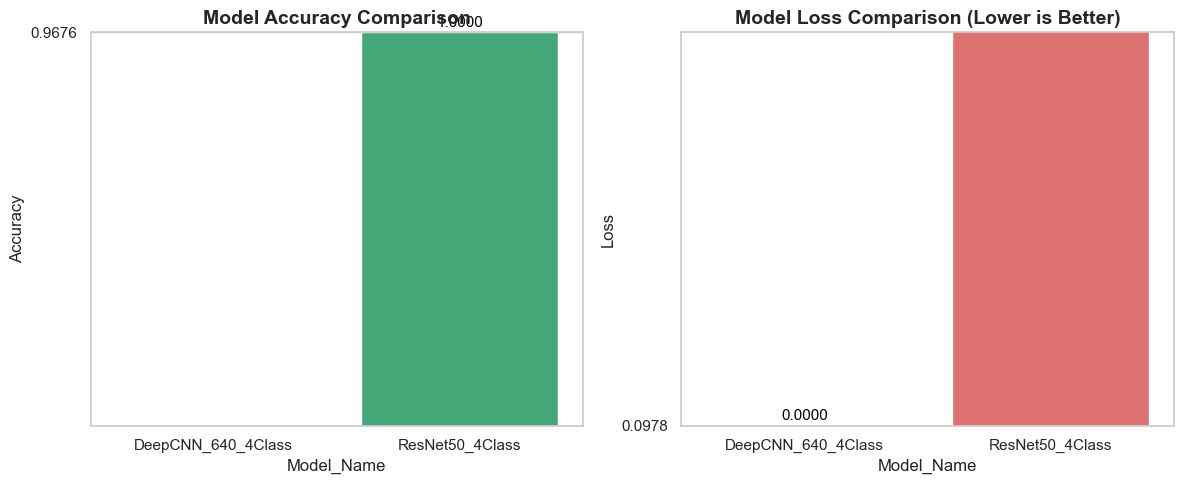

In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

# 1. 데이터 로드 (파일이 있는 경로로 수정하세요)
df = pd.read_csv('final_model_comparison.csv')

df = df[df['Model_Name'].isin(['DeepCNN_640_4Class', 'ResNet50_4Class'])]

display(df)
# 2. 그래프 스타일 설정
sns.set_theme(style="whitegrid")
fig, ax1 = plt.subplots(1, 2, figsize=(12, 5))

# --- 그래프 1: Accuracy 비교 ---
sns.barplot(x='Model_Name', y='Accuracy', data=df, ax=ax1[0], palette='viridis')
ax1[0].set_title('Model Accuracy Comparison', fontsize=14, fontweight='bold')
ax1[0].set_ylim(0.93, 1.0)  # 차이를 명확히 보기 위해 범위 조절
for p in ax1[0].patches:
    ax1[0].annotate(f'{p.get_height():.4f}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', fontsize=11, color='black', xytext=(0, 7),
                textcoords='offset points')

# --- 그래프 2: Loss 비교 ---
sns.barplot(x='Model_Name', y='Loss', data=df, ax=ax1[1], palette='magma')
ax1[1].set_title('Model Loss Comparison (Lower is Better)', fontsize=14, fontweight='bold')
ax1[1].set_ylim(0, 0.15)
for p in ax1[1].patches:
    ax1[1].annotate(f'{p.get_height():.4f}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', fontsize=11, color='black', xytext=(0, 7),
                textcoords='offset points')

plt.tight_layout()
plt.savefig('model_comparison_result.png', dpi=300) # 300dpi 고화질 저장
plt.show()

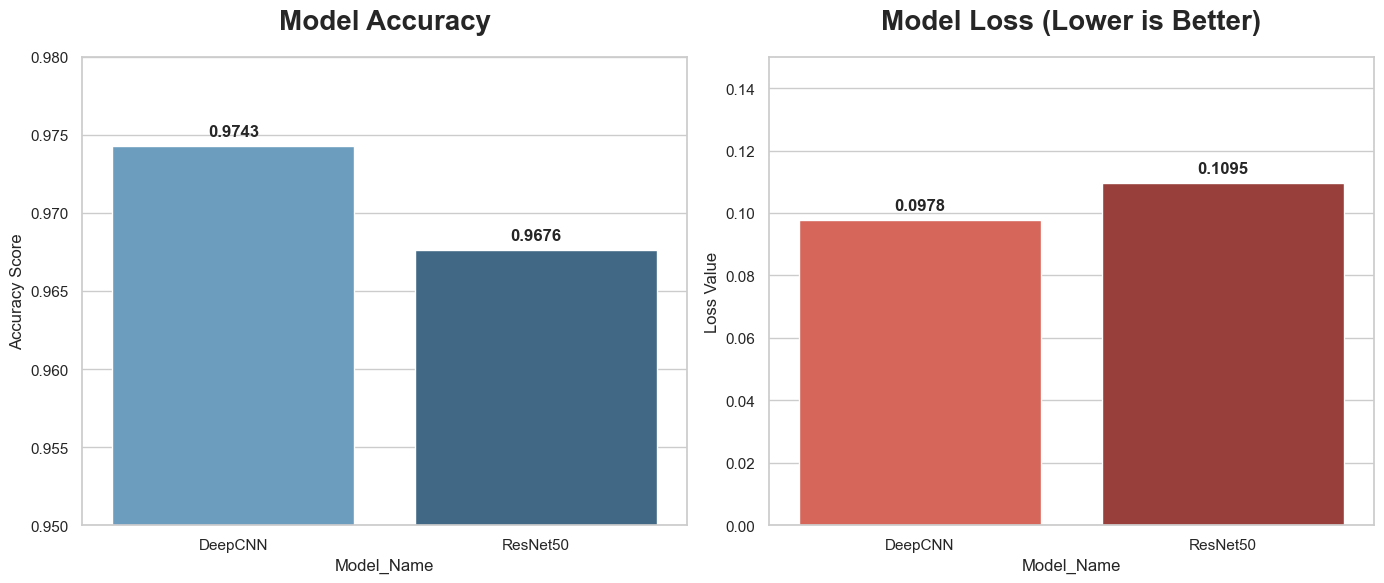

In [14]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. 데이터 설정
data = {
    'Model_Name': ['DeepCNN', 'ResNet50'], # 이름이 길면 그래프가 깨지니 짧게 수정
    'Accuracy': [0.9743, 0.9676],
    'Loss': [0.0978, 0.1095]
}
df = pd.DataFrame(data)

# 2. 스타일 설정
sns.set_theme(style="whitegrid")
fig, ax1 = plt.subplots(1, 2, figsize=(14, 6))

# --- [좌측] Accuracy 차트 ---
# y축 범위를 데이터의 최솟값보다 살짝 낮게 설정하여 차이를 강조합니다.
sns.barplot(x='Model_Name', y='Accuracy', data=df, ax=ax1[0], palette='Blues_d')
ax1[0].set_title('Model Accuracy', fontsize=20, fontweight='bold', pad=20)
ax1[0].set_ylim(0.95, 0.98) # 범위를 0.95 ~ 0.98로 고정
ax1[0].set_ylabel('Accuracy Score')

# 막대 위에 숫자 표시
for p in ax1[0].patches:
    ax1[0].annotate(f'{p.get_height():.4f}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', fontsize=12, fontweight='bold', xytext=(0, 5),
                textcoords='offset points')

# --- [우측] Loss 차트 ---
sns.barplot(x='Model_Name', y='Loss', data=df, ax=ax1[1], palette='Reds_d')
ax1[1].set_title('Model Loss (Lower is Better)', fontsize=20, fontweight='bold', pad=20)
ax1[1].set_ylim(0, 0.15) # 범위를 0 ~ 0.15로 설정하여 막대가 잘 보이게 함
ax1[1].set_ylabel('Loss Value')

# 막대 위에 숫자 표시
for p in ax1[1].patches:
    ax1[1].annotate(f'{p.get_height():.4f}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', fontsize=12, fontweight='bold', xytext=(0, 5),
                textcoords='offset points')

plt.tight_layout()
plt.show()

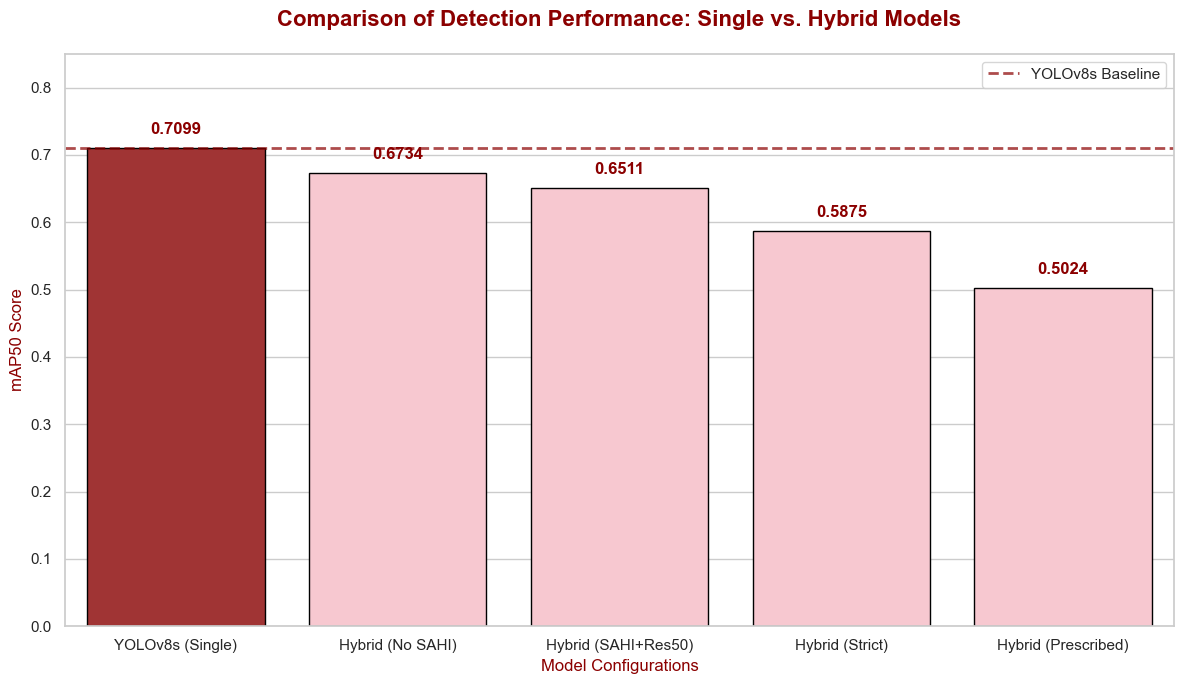

In [16]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. 데이터 구성 (실측 데이터 반영)
data = {
    'Model_Variant': [
        'YOLOv8s (Single)', 
        'Hybrid (No SAHI)', 
        'Hybrid (SAHI+Res50)', 
        'Hybrid (Strict)', 
        'Hybrid (Prescribed)'
    ],
    'mAP50': [0.7099, 0.6734, 0.6511, 0.5875, 0.5024]
}
df = pd.DataFrame(data)

# 2. 그래프 스타일 및 크기 설정
sns.set_theme(style="whitegrid")
plt.figure(figsize=(12, 7))

# 3. 막대 그래프 그리기 (빨간색 톤으로 변경 및 단일 모델 강조)
# YOLOv8s는 진한 빨간색, 하이브리드들은 연한 분홍/빨강 톤으로 설정
colors = ['#B22222'] + ['#FFC0CB'] * 4  # Firebrick Red + Pink
ax = sns.barplot(x='Model_Variant', y='mAP50', data=df, palette=colors, edgecolor='black', linewidth=1)

# 4. 차트 디테일 설정
plt.title('Comparison of Detection Performance: Single vs. Hybrid Models', fontsize=16, fontweight='bold', color='#8B0000', pad=20)
plt.ylabel('mAP50 Score', fontsize=12, color='#8B0000')
plt.xlabel('Model Configurations', fontsize=12, color='#8B0000')
plt.ylim(0, 0.85)  # Y축 범위 설정

# 5. 막대 위에 수치 표시 (Data Labeling)
for p in ax.patches:
    ax.annotate(f'{p.get_height():.4f}', 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='bottom', fontsize=12, fontweight='bold', color='#8B0000', xytext=(0, 8),
                textcoords='offset points')

# 6. 기준선 추가 (YOLOv8s 단독 성능선 - 더 진한 빨간색으로 변경)
plt.axhline(y=0.7099, color='#8B0000', linestyle='--', alpha=0.7, linewidth=2, label='YOLOv8s Baseline')
plt.legend(loc='upper right', fontsize=11)

plt.tight_layout()
plt.show()

모델 로드 성공!

image 1/1 c:\workspace_bigdata\deeplearning\mini\classification_data\train\fire\AoF04010.jpg_1.jpg: 352x640 (no detections), 29.9ms
Speed: 3.1ms preprocess, 29.9ms inference, 2.0ms postprocess per image at shape (1, 3, 352, 640)


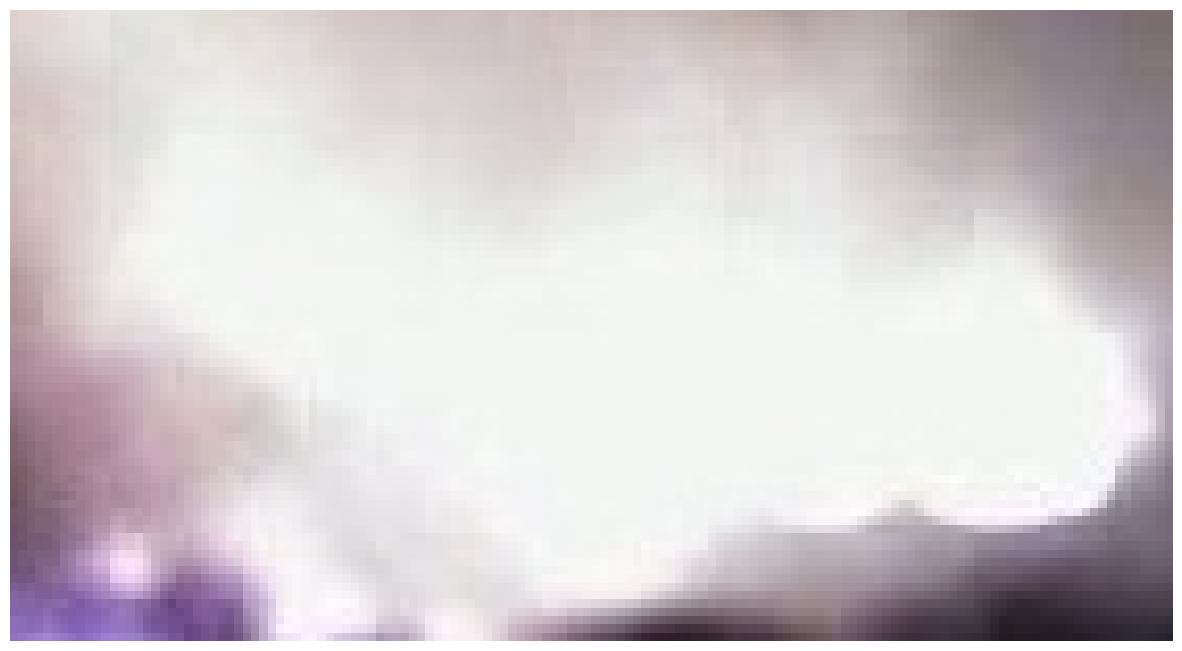

In [24]:
import cv2
import torch
from ultralytics import YOLO
from torchvision import transforms
from PIL import Image
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torchvision import models, transforms

# 1. 모델 구조 정의 (학습할 때 사용했던 것과 동일해야 함)
def load_classifier(pth_path):
    # 1. ResNet50 기본 구조 로드
    model = models.resnet50(weights=None)
    num_ftrs = model.fc.in_features
    
    # 2. 에러 해결 핵심: Sequential 대신 단일 Linear 레이어로 정의
    # 에러 메시지에서 'fc.weight'를 기대하므로, nn.Sequential을 쓰지 않습니다.
    model.fc = nn.Linear(num_ftrs, 3) 
    
    # 3. 가중치 로드
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    state_dict = torch.load(pth_path, map_location=device)
    
    # 가중치 입히기
    model.load_state_dict(state_dict)
    model.to(device)
    model.eval()
    
    print("모델 로드 성공!")
    return model

# 호출 부분
classifier = load_classifier('best_ResNet50.pth')
# 1. 모델 로드
yolo_model = YOLO('runs/detect/Wildfire_Project/v8s_fire_smoke_run/weights/best.pt') # 탐지 모델
classifier.eval()

# 2. 분류기용 전처리 설정 (우리가 했던 640x640 정규화 방식)
preprocess = transforms.Compose([
    transforms.Resize((640, 640)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

def hybrid_inference(image_path):
    img = cv2.imread(image_path)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    results = yolo_model(image_path)[0]
    
    plt.figure(figsize=(15, 10))
    plt.imshow(img_rgb)
    ax = plt.gca()

    for box in results.boxes:
        # YOLO가 찾은 좌표
        x1, y1, x2, y2 = map(int, box.xyxy[0])
        conf = box.conf[0].item()
        
        # 3. 영역 크롭 및 분류기 검증
        crop = img_rgb[y1:y2, x1:x2]
        crop_pil = Image.fromarray(crop)
        input_tensor = preprocess(crop_pil).unsqueeze(0)
        
        with torch.no_grad():
            output = classifier(input_tensor)
            prob = torch.nn.functional.softmax(output, dim=1)
            pred_idx = torch.argmax(prob).item()
            # 클래스 정의: 0: Fire, 1: Smoke, 2: Background(안개/구름 등)
            labels = ['Fire', 'Smoke', 'Background']
            final_label = labels[pred_idx]

        # 4. 시각화 로직
        if final_label == 'Background':
            # [오탐 방지 케이스] YOLO는 찾았으나 분류기가 제거함
            rect = plt.Rectangle((x1, y1), x2-x1, y2-y1, fill=False, color='blue', linewidth=2, linestyle='--')
            plt.text(x1, y1-10, f'Filtered: {final_label}', color='blue', weight='bold')
        else:
            # [정상 탐지 혹은 미탐 가능성] 분류기가 통과시킴
            rect = plt.Rectangle((x1, y1), x2-x1, y2-y1, fill=False, color='red', linewidth=3)
            plt.text(x1, y1-10, f'Detected: {final_label} ({conf:.2f})', color='red', weight='bold')
        
        ax.add_patch(rect)

    plt.axis('off')
    plt.show()

# 실행
hybrid_inference('classification_data/train/fire/AoF04010.jpg_1.jpg')

In [25]:
import os
import cv2
import torch
import numpy as np
from ultralytics import YOLO
from torchvision import transforms
from PIL import Image

# 1. 설정 (경로 및 모델)
YOLO_PATH = 'runs/detect/Wildfire_Project/v8s_fire_smoke_run/weights/best.pt'
CLS_PATH = 'best_ResNet50.pth'
INPUT_DIR = 'data/test/images'  # 분석할 사진들이 있는 폴더
OUTPUT_DIR = './analysis_results/' # 결과가 저장될 폴더
os.makedirs(OUTPUT_DIR, exist_ok=True)

yolo_model = YOLO(YOLO_PATH)
# 이전 단계에서 수정했던 분류기 로드 함수를 사용하세요
classifier = load_classifier(CLS_PATH) 

preprocess = transforms.Compose([
    transforms.Resize((640, 640)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

def analyze_folder():
    for img_name in os.listdir(INPUT_DIR):
        if not img_name.lower().endswith(('.jpg', '.jpeg', '.png')): continue
        
        img_path = os.path.join(INPUT_DIR, img_name)
        img = cv2.imread(img_path)
        img_yolo = img.copy()    # 왼쪽: YOLO 단독 결과용
        img_hybrid = img.copy()  # 오른쪽: 하이브리드 결과용
        
        results = yolo_model(img_path)[0]
        
        for box in results.boxes:
            x1, y1, x2, y2 = map(int, box.xyxy[0])
            conf = box.conf[0].item()
            
            # --- 1. YOLO 단독 표시 (초록색 실선) ---
            cv2.rectangle(img_yolo, (x1, y1), (x2, y2), (0, 255, 0), 3)
            cv2.putText(img_yolo, f'YOLO:{conf:.2f}', (x1, y1-10), cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 255, 0), 2)

            # --- 2. 하이브리드 검증 ---
            crop = cv2.cvtColor(img[y1:y2, x1:x2], cv2.COLOR_BGR2RGB)
            crop_pil = Image.fromarray(crop)
            input_tensor = preprocess(crop_pil).unsqueeze(0).to(next(classifier.parameters()).device)
            
            with torch.no_grad():
                output = classifier(input_tensor)
                pred_idx = torch.argmax(output).item()
                labels = ['Fire', 'Smoke', 'Background']
                final_label = labels[pred_idx]

            # --- 3. 하이브리드 표시 ---
            if final_label == 'Background':
                # 필터링 됨 (파란색 점선 느낌의 얇은 선)
                cv2.rectangle(img_hybrid, (x1, y1), (x2, y2), (255, 0, 0), 2)
                cv2.putText(img_hybrid, 'Filtered(BG)', (x1, y1-10), cv2.FONT_HERSHEY_SIMPLEX, 0.7, (255, 0, 0), 2)
            else:
                # 최종 통과 (빨간색 두꺼운 실선)
                cv2.rectangle(img_hybrid, (x1, y1), (x2, y2), (0, 0, 255), 4)
                cv2.putText(img_hybrid, f'Hybrid:{final_label}', (x1, y1-10), cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 0, 255), 2)

        # 두 이미지를 가로로 합치기 (비교용)
        combined = np.hstack((img_yolo, img_hybrid))
        cv2.imwrite(os.path.join(OUTPUT_DIR, f'analysis_{img_name}'), combined)

    print(f"분석 완료! {OUTPUT_DIR} 폴더를 확인하세요.")

analyze_folder()

모델 로드 성공!

image 1/1 c:\workspace_bigdata\deeplearning\mini\data\test\images\AoF06723.jpg: 384x640 (no detections), 33.4ms
Speed: 2.2ms preprocess, 33.4ms inference, 1.0ms postprocess per image at shape (1, 3, 384, 640)

image 1/1 c:\workspace_bigdata\deeplearning\mini\data\test\images\AoF06724.jpg: 352x640 (no detections), 11.3ms
Speed: 1.7ms preprocess, 11.3ms inference, 0.7ms postprocess per image at shape (1, 3, 352, 640)

image 1/1 c:\workspace_bigdata\deeplearning\mini\data\test\images\AoF06725.jpg: 384x640 (no detections), 11.0ms
Speed: 2.3ms preprocess, 11.0ms inference, 0.5ms postprocess per image at shape (1, 3, 384, 640)

image 1/1 c:\workspace_bigdata\deeplearning\mini\data\test\images\AoF06726.jpg: 384x640 (no detections), 10.0ms
Speed: 2.1ms preprocess, 10.0ms inference, 0.6ms postprocess per image at shape (1, 3, 384, 640)

image 1/1 c:\workspace_bigdata\deeplearning\mini\data\test\images\AoF06727.jpg: 384x640 (no detections), 9.7ms
Speed: 2.1ms preprocess, 9.7ms inferen

In [26]:
import os
import cv2
import torch
import numpy as np
from ultralytics import YOLO
from torchvision import transforms
from PIL import Image

# 1. 경로 설정
INPUT_DIR = 'data/test/images'  # 원본 이미지 폴더
BASE_OUTPUT = './analysis_results/'
# 세부 폴더 생성
sub_dirs = ['1_FP_Removed(Good)', '2_FN_Generated(Bad)', '3_Normal_Detection']
for sd in sub_dirs:
    os.makedirs(os.path.join(BASE_OUTPUT, sd), exist_ok=True)

# 2. 모델 로드 (기존에 정의한 load_classifier 함수 사용)
yolo_model = YOLO('runs/detect/Wildfire_Project/v8s_fire_smoke_run/weights/best.pt')
classifier = load_classifier('best_ResNet50.pth')

preprocess = transforms.Compose([
    transforms.Resize((640, 640)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

def analyze_and_classify():
    for img_name in os.listdir(INPUT_DIR):
        if not img_name.lower().endswith(('.jpg', '.png')): continue
        
        img_path = os.path.join(INPUT_DIR, img_name)
        img = cv2.imread(img_path)
        results = yolo_model(img_path)[0]
        
        has_fn = False  # 미탐 발생 여부
        has_fp_removed = False # 오탐 제거 여부

        for box in results.boxes:
            x1, y1, x2, y2 = map(int, box.xyxy[0])
            conf = box.conf[0].item()
            yolo_label = results.names[int(box.cls[0])] # YOLO가 예측한 클래스

            # 분류기 검증
            crop = cv2.cvtColor(img[max(0,y1):y2, max(0,x1):x2], cv2.COLOR_BGR2RGB)
            crop_pil = Image.fromarray(crop)
            input_tensor = preprocess(crop_pil).unsqueeze(0).to(next(classifier.parameters()).device)
            
            with torch.no_grad():
                output = classifier(input_tensor)
                pred_idx = torch.argmax(output).item()
                labels = ['Fire', 'Smoke', 'Background']
                final_label = labels[pred_idx]

            # --- 로직 분석 ---
            # 1. 미탐(FN) 발생: 실제 불/연기인데 분류기가 Background라고 함
            if final_label == 'Background':
                cv2.rectangle(img, (x1, y1), (x2, y2), (255, 0, 0), 2) # 파란색 (삭제됨)
                cv2.putText(img, f"Removed: {yolo_label}", (x1, y1-10), 
                            cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255, 0, 0), 2)
                has_fn = True 
            
            # 2. 정상 탐지: YOLO와 분류기 의견 일치
            else:
                cv2.rectangle(img, (x1, y1), (x2, y2), (0, 0, 255), 3) # 빨간색 (최종통과)
                cv2.putText(img, f"Final: {final_label}", (x1, y1-10), 
                            cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 0, 255), 2)

        # --- 폴더 분류 저장 ---
        # 실제 데이터셋의 정답(Ground Truth)과 비교하는 로직이 없으므로, 
        # 육안 확인을 위해 '삭제된 박스가 있는 사진'은 Bad 폴더로 우선 분류합니다.
        if has_fn:
            save_path = os.path.join(BASE_OUTPUT, sub_dirs[1], img_name)
        elif not has_fn and len(results.boxes) > 0:
            save_path = os.path.join(BASE_OUTPUT, sub_dirs[2], img_name)
        else:
            continue
            
        cv2.imwrite(save_path, img)

    print("✅ 모든 사진 분석 및 폴더 분류 완료!")

analyze_and_classify()

모델 로드 성공!

image 1/1 c:\workspace_bigdata\deeplearning\mini\data\test\images\AoF06723.jpg: 384x640 (no detections), 10.9ms
Speed: 1.8ms preprocess, 10.9ms inference, 0.6ms postprocess per image at shape (1, 3, 384, 640)

image 1/1 c:\workspace_bigdata\deeplearning\mini\data\test\images\AoF06724.jpg: 352x640 (no detections), 10.3ms
Speed: 1.9ms preprocess, 10.3ms inference, 0.5ms postprocess per image at shape (1, 3, 352, 640)

image 1/1 c:\workspace_bigdata\deeplearning\mini\data\test\images\AoF06725.jpg: 384x640 (no detections), 10.5ms
Speed: 1.9ms preprocess, 10.5ms inference, 0.5ms postprocess per image at shape (1, 3, 384, 640)

image 1/1 c:\workspace_bigdata\deeplearning\mini\data\test\images\AoF06726.jpg: 384x640 (no detections), 9.7ms
Speed: 1.9ms preprocess, 9.7ms inference, 0.6ms postprocess per image at shape (1, 3, 384, 640)

image 1/1 c:\workspace_bigdata\deeplearning\mini\data\test\images\AoF06727.jpg: 384x640 (no detections), 9.6ms
Speed: 1.7ms preprocess, 9.6ms inference